# Предиктивная аналитика ветроэнергетической установки

## Учебный ноутбук для студентов: разведочный анализ данных и классификация режимов отказа

В работе рассматривается полный конвейер построения системы предиктивной аналитики (predictive maintenance) для промышленной ветроэнергетической установки (ВЭУ) на основе данных, регистрируемых системой диспетчерского управления и сбора данных (SCADA — Supervisory Control and Data Acquisition).

### Цели работы
1. Освоить методологию **разведочного анализа данных** (EDA) применительно к временным рядам промышленных датчиков.
2. Понять структуру данных SCADA-системы и журналов событий ВЭУ.
3. Освоить корректное **объединение разнородных источников** временных данных через `pandas.merge_asof`.
4. Изучить методы **обнаружения выбросов** (IQR), **корреляционного анализа** и **кривой мощности** как индустриально-стандартного диагностического инструмента.
5. Освоить алгоритмы балансировки несбалансированных классов (**SMOTE**) и обучение классификатора на основе градиентного бустинга (**LightGBM**).
6. Понять процедуру **подбора гиперпараметров** на основе сеточного поиска со стратифицированной кросс-валидацией.
7. Провести сравнительный анализ моделей и обсудить ограничения подхода.

### Структура работы
| Раздел | Содержание |
|---|---|
| 1 | Подготовка окружения, загрузка данных |
| 2 | Общий обзор: типы, пропуски, статистики |
| 3 | Анализ временного покрытия источников |
| 4 | Журнал отказов: распределения, сезонность |
| 5 | Журнал статусов: режимы работы |
| 6 | Телеметрия SCADA: распределения, выбросы, корреляции |
| 7 | Кривая мощности и эксплуатационные показатели |
| 8 | Подготовка данных для машинного обучения |
| 9 | Классификация: LightGBM + SMOTE |
| 10 | Подбор гиперпараметров (Grid Search) |
| 11 | Сравнение с базовой моделью (Decision Tree) |
| 12 | Сводные выводы и направления развития |

### Исходные данные
В работе используются три CSV-файла, полученные с реальной ВЭУ:

| Файл | Размер | Описание |
|---|---|---|
| `scada_data.csv` | ≈49 028 строк × 66 столбцов | Телеметрия SCADA с шагом ≈10 минут (скорость ветра, мощность, температуры компонентов) |
| `fault_data.csv` | ≈553 строки × 3 столбца | Журнал отказов с типом неисправности |
| `status_data.csv` | ≈1 849 строк × 9 столбцов | Журнал событий смены режимов работы |

Исходный набор данных доступен в открытом репозитории [lkev/wt-fdd на GitHub](https://github.com/lkev/wt-fdd).

### Расшифровка кодов отказов

| Код | Расшифровка | Физическое значение |
|---|---|---|
| `GF` | Generator Heating Fault | Перегрев генератора |
| `MF` | Mains Failure Fault | Отказ питающей электросети (внешний фактор) |
| `FF` | Feeding Fault | Отказ системы подачи / преобразования |
| `AF` | Air Cooling Fault | Отказ системы воздушного охлаждения |
| `EF` | Excitation Fault | Отказ системы возбуждения генератора |
| `NF` | No Fault | Нормальный режим (вводится при разметке SCADA) |


## 0. Подключение библиотек

### Используемые программные средства

| Библиотека | Назначение | Документация |
|---|---|---|
| NumPy | Линейная алгебра, численные операции | [numpy.org](https://numpy.org/doc/) |
| pandas | Работа с табличными данными и временными рядами | [pandas.pydata.org](https://pandas.pydata.org/docs/) |
| Matplotlib | Базовые средства визуализации | [matplotlib.org](https://matplotlib.org/) |
| Seaborn | Статистическая визуализация | [seaborn.pydata.org](https://seaborn.pydata.org/) |
| missingno | Визуализация пропусков в данных | [GitHub: ResidentMario/missingno](https://github.com/ResidentMario/missingno) |
| scikit-learn | Алгоритмы машинного обучения, метрики, разбиения | [scikit-learn.org](https://scikit-learn.org/stable/) |
| imbalanced-learn | Балансировка классов (SMOTE и др.) | [imbalanced-learn.org](https://imbalanced-learn.org/stable/) |
| LightGBM | Градиентный бустинг на деревьях решений | [lightgbm.readthedocs.io](https://lightgbm.readthedocs.io/) |

**Замечание.** Пакет `sklearn` (без префикса `scikit-`) является устаревшей заглушкой, его установка приведёт к ошибке. Корректное имя пакета — `scikit-learn`.


In [ ]:
# Установка дополнительных пакетов, не входящих в стандартную среду Colab
!pip install -q imbalanced-learn lightgbm missingno

In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Инструменты scikit-learn
from sklearn.model_selection import (
    train_test_split, cross_validate, StratifiedKFold, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, mean_squared_error
)
from sklearn.tree import DecisionTreeClassifier

# Балансировка классов
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import make_pipeline

# Градиентный бустинг
from lightgbm import LGBMClassifier

# Настройки отображения
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 180)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11

print('Версии библиотек:')
print(f'  pandas : {pd.__version__}')
print(f'  numpy  : {np.__version__}')
print(f'  seaborn: {sns.__version__}')

Версии библиотек:
  pandas : 2.2.2
  numpy  : 2.0.2
  seaborn: 0.13.2


## 1. Загрузка данных

Перед запуском ноутбука в Google Colab необходимо загрузить три CSV-файла в рабочий каталог. Это можно сделать двумя способами:

**Способ 1: через панель «Файлы».**
Открыть иконку папки в левой панели Colab и перетащить файлы `scada_data.csv`, `fault_data.csv`, `status_data.csv`.

**Способ 2: смонтировать Google Drive:**
```python
from google.colab import drive
drive.mount('/content/drive')
DATA_DIR = '/content/drive/MyDrive/wind_turbine'
```

После выполнения ячейки ниже путь `DATA_DIR` будет содержать каталог с данными.


In [3]:
# По умолчанию данные ожидаются в рабочем каталоге Colab
DATA_DIR = '.'  # либо укажите путь, например: '/content/drive/MyDrive/wind_turbine'

# Загрузка всех трёх источников
scada  = pd.read_csv(os.path.join(DATA_DIR, 'scada_data.csv'))
status = pd.read_csv(os.path.join(DATA_DIR, 'status_data.csv'))
faults = pd.read_csv(os.path.join(DATA_DIR, 'fault_data.csv'))

# Приведение временных столбцов к типу datetime
scada['DateTime']  = pd.to_datetime(scada['DateTime'], errors='coerce')
status['Time']     = pd.to_datetime(status['Time'], dayfirst=True, errors='coerce')
faults['DateTime'] = pd.to_datetime(faults['DateTime'], errors='coerce')

# Сортировка по времени (необходима для merge_asof далее)
scada  = scada.sort_values('DateTime').reset_index(drop=True)
status = status.sort_values('Time').reset_index(drop=True)
faults = faults.sort_values('DateTime').reset_index(drop=True)

print(f'SCADA  : {scada.shape[0]:>6} строк, {scada.shape[1]:>3} столбцов')
print(f'Status : {status.shape[0]:>6} строк, {status.shape[1]:>3} столбцов')
print(f'Faults : {faults.shape[0]:>6} строк, {faults.shape[1]:>3} столбцов')

SCADA  :  49027 строк,  66 столбцов
Status :   1849 строк,   9 столбцов
Faults :    553 строк,   3 столбцов


### Замечания по парсингу дат

В файле `status_data.csv` даты записаны в европейском формате `DD/MM/YYYY`. По умолчанию `pd.to_datetime` использует формат `MM/DD/YYYY` (американский), что приведёт к некорректной интерпретации (например, `04/05/2014` будет прочитано как 5 апреля вместо 4 мая). Параметр `dayfirst=True` устраняет эту неоднозначность.

Параметр `errors='coerce'` заменяет некорректные значения на `NaT` (Not a Time) вместо генерации исключения. Это позволяет проводить дальнейший анализ даже при наличии локальных ошибок в исходных данных.


## 2. Общий обзор таблиц

### Зачем нужен общий обзор

До любого содержательного анализа необходимо зафиксировать:
- **типы данных** в каждом столбце (числовые, категориальные, временные);
- **число и долю пропусков** — это влияет на стратегию обработки;
- **число уникальных значений** — позволяет отличить категориальный признак с малым числом уровней от числового;
- **базовые статистики** (минимум, максимум, среднее, квартили) — обнаруживают физически невозможные значения и грубые ошибки.

Этот шаг позволяет на ранней стадии обнаружить **систематические дефекты данных** (массовые пропуски, неверные типы, перепутанные кодировки).


In [4]:
def overview(df: pd.DataFrame, name: str) -> pd.DataFrame:
    # Сводка по таблице: тип столбца, число и доля пропусков, число уникальных значений
    summary = pd.DataFrame({
        'dtype':       df.dtypes.astype(str),
        'n_missing':   df.isna().sum(),
        'pct_missing': (df.isna().mean() * 100).round(2),
        'n_unique':    df.nunique(dropna=True),
    })
    print(f'=== {name} === shape = {df.shape}')
    return summary

overview(faults, 'fault_data').head(20)

=== fault_data === shape = (553, 3)


,dtype,n_missing,pct_missing,n_unique
DateTime,datetime64[ns],0,0.000,446
Time,float64,0,0.000,446
Fault,object,0,0.000,5


In [5]:
overview(status, 'status_data').head(20)

=== status_data === shape = (1849, 9)


,dtype,n_missing,pct_missing,n_unique
Time,datetime64[ns],0,0.000,1815
Main Status,int64,0,0.000,29
Sub Status,int64,0,0.000,36
Full Status,object,0,0.000,58
Status Text,object,0,0.000,56
T,int64,0,0.000,4
Service,bool,0,0.000,2
FaultMsg,bool,0,0.000,2
Value0,float64,0,0.000,227


In [6]:
overview(scada, 'scada_data').head(30)

=== scada_data === shape = (49027, 66)


,dtype,n_missing,pct_missing,n_unique
DateTime,datetime64[ns],0,0.000,49017
Time,int64,0,0.000,49021
Error,int64,0,0.000,12
WEC: ava. windspeed,float64,0,0.000,254
WEC: max. windspeed,float64,0,0.000,360
WEC: min. windspeed,float64,0,0.000,177
WEC: ava. Rotation,float64,0,0.000,1413
WEC: max. Rotation,float64,0,0.000,1548
WEC: min. Rotation,float64,0,0.000,1361
WEC: ava. Power,int64,0,0.000,3067


### Приведение булевых столбцов

В журнале статусов столбцы `Service` (планово-предупредительное обслуживание) и `FaultMsg` (наличие аварийного сообщения) прочитаны как строки `'TRUE'`/`'FALSE'`. Необходимо привести их к настоящему булевому типу.


In [7]:
for col in ['Service', 'FaultMsg']:
    status[col] = status[col].map({'TRUE': True, 'FALSE': False,
                                    True: True,   False: False})

print('Типы столбцов после приведения:')
print(status[['Service', 'FaultMsg']].dtypes)

Типы столбцов после приведения:
Service     bool
FaultMsg    bool
dtype: object


## 3. Анализ временного покрытия

### Ключевая методологическая идея

Прежде чем объединять данные из трёх источников, необходимо **убедиться, что их временные диапазоны действительно пересекаются**. Если, например, SCADA содержит данные за 2014–2015 годы, а журнал отказов — только за май–декабрь 2014, то записи SCADA вне этого периода нельзя автоматически считать «нормальным режимом» — они просто **не размечены**.

Это критически важный момент, который часто упускается в учебных работах. Игнорирование разрыва в покрытии приводит к **систематическому смещению меток** и завышенным оценкам качества модели.


In [8]:
# Вспомогательная функция для печати временного диапазона
def time_range(df, col, name):
    print(f'{name:<8}: с {df[col].min()}  по  {df[col].max()}  '
          f'(длительность: {df[col].max() - df[col].min()})')

time_range(scada,  'DateTime', 'SCADA')
time_range(status, 'Time',     'Status')
time_range(faults, 'DateTime', 'Faults')

SCADA   : с 2014-05-01 00:00:00  по  2015-04-09 00:00:00  (длительность: 343 days 00:00:00)
Status  : с 2014-04-24 12:37:38  по  2015-04-28 22:18:19  (длительность: 369 days 09:40:41)
Faults  : с 2014-05-14 14:39:44  по  2015-01-15 23:09:20  (длительность: 246 days 08:29:36)


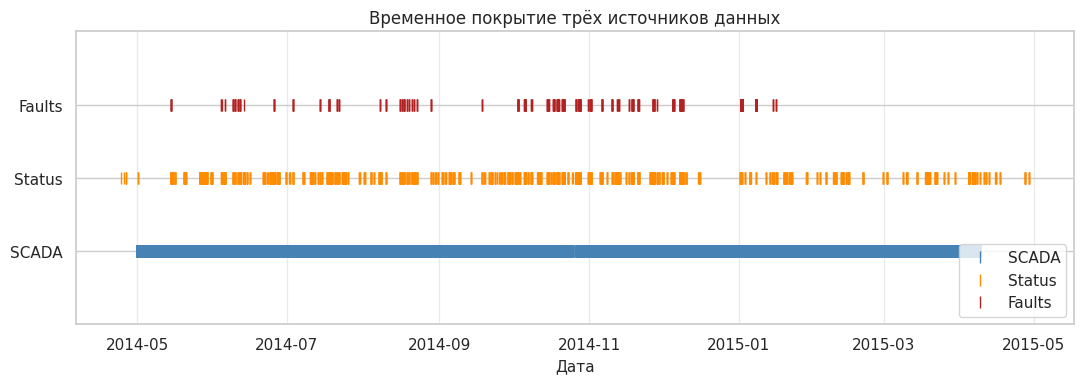

In [9]:
# Визуализация временного покрытия
t_scada  = scada['DateTime']
t_status = status['Time']
t_fault  = faults['DateTime']

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(t_scada,  np.full(len(t_scada),  1), '|', markersize=8,
        color='steelblue', label='SCADA')
ax.plot(t_status, np.full(len(t_status), 2), '|', markersize=8,
        color='darkorange', label='Status')
ax.plot(t_fault,  np.full(len(t_fault),  3), '|', markersize=8,
        color='firebrick', label='Faults')

ax.set_ylim(0, 4)
ax.set_yticks([1, 2, 3])
ax.set_yticklabels(['SCADA', 'Status', 'Faults'])
ax.set_xlabel('Дата')
ax.set_title('Временное покрытие трёх источников данных')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.4, axis='x')
plt.tight_layout()
plt.show()

In [10]:
# Количественная оценка пересечения периодов
common_start = max(t_scada.min(), t_status.min(), t_fault.min())
common_end   = min(t_scada.max(), t_status.max(), t_fault.max())

in_common = (scada['DateTime'] >= common_start) & (scada['DateTime'] <= common_end)
share_in  = in_common.mean() * 100
share_out = (1 - in_common.mean()) * 100

print(f'Общий период пересечения: с {common_start}  по  {common_end}')
print(f'Длительность пересечения: {common_end - common_start}')
print()
print(f'SCADA-записей внутри пересечения: {in_common.sum():>6} ({share_in:.1f} %)')
print(f'SCADA-записей вне  пересечения:   {(~in_common).sum():>6} ({share_out:.1f} %)')

Общий период пересечения: с 2014-05-14 14:39:44  по  2015-01-15 23:09:20
Длительность пересечения: 246 days 08:29:36

SCADA-записей внутри пересечения:  35168 (71.7 %)
SCADA-записей вне  пересечения:    13859 (28.3 %)


**Вывод.** Записи SCADA, лежащие вне общего периода, **не могут быть автоматически размечены как `NF`**. Дальнейший анализ будет проводиться только на пересечении.

### Анализ шага дискретизации

Шаг дискретизации SCADA определяет временное разрешение модели. В индустрии стандартным является **10-минутное** агрегированное окно (по соглашению IEC 61400-12).


In [11]:
scada_dt = scada['DateTime'].diff().dropna()
print('Распределение интервалов между соседними записями SCADA:')
print(scada_dt.describe())

# Разрывы длительностью более 15 минут указывают на пропуски в записи
long_gaps = scada_dt[scada_dt > pd.Timedelta(minutes=15)]
print(f'\nЧисло разрывов длительностью более 15 минут: {len(long_gaps)}')
print(f'Суммарная длительность таких разрывов: {long_gaps.sum()}')

Распределение интервалов между соседними записями SCADA:
count                        49026
mean     0 days 00:10:04.479255905
std      0 days 00:09:53.534904554
min                0 days 00:00:00
25%                0 days 00:09:00
50%                0 days 00:10:00
75%                0 days 00:11:00
max                1 days 10:31:00
Name: DateTime, dtype: object

Число разрывов длительностью более 15 минут: 13
Суммарная длительность таких разрывов: 2 days 17:38:00


### Визуализация полноты записей: heatmap по дням

Удобный способ увидеть структуру пропусков — heatmap, где каждая ячейка соответствует одному дню, а её цвет показывает **долю заполненности** (число фактических записей к теоретически ожидаемому). При 10-минутном шаге в сутках должно быть 144 записи.


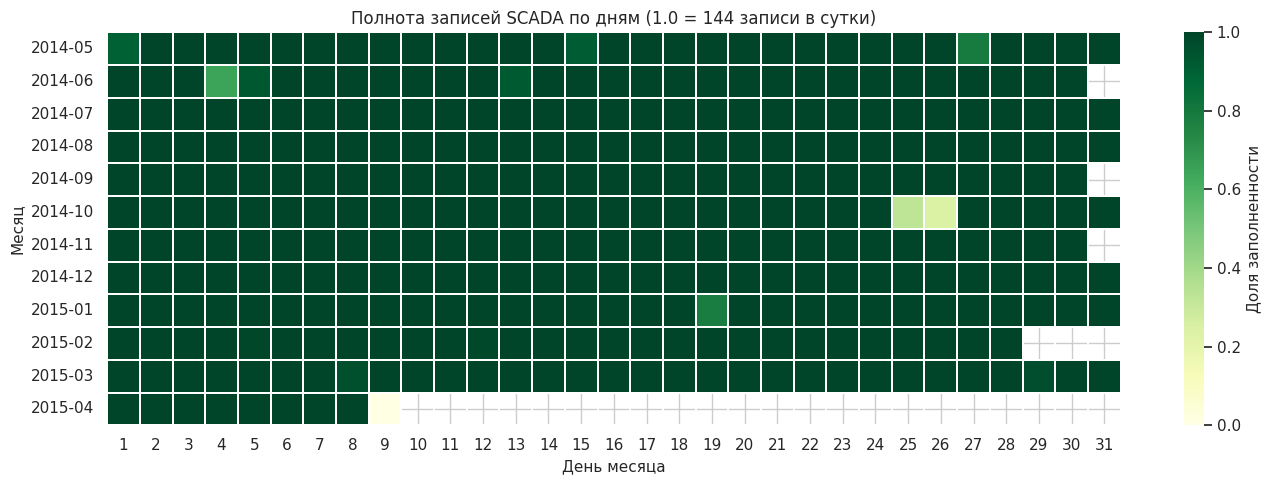

In [12]:
# Доля заполненности по дням
scada['date'] = scada['DateTime'].dt.date
daily_count = scada.groupby('date').size()
expected_per_day = 144  # 24 ч × 6 записей/час
daily_fill = (daily_count / expected_per_day).clip(upper=1.0)

# Преобразование в матрицу: строки — месяцы, столбцы — день месяца
daily_df = pd.DataFrame({
    'date': pd.to_datetime(daily_fill.index),
    'fill': daily_fill.values
})
daily_df['year_month'] = daily_df['date'].dt.strftime('%Y-%m')
daily_df['day'] = daily_df['date'].dt.day
heat = daily_df.pivot_table(index='year_month', columns='day', values='fill')

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heat, cmap='YlGn', vmin=0, vmax=1, cbar_kws={'label': 'Доля заполненности'},
            linewidths=0.3, ax=ax)
ax.set_title('Полнота записей SCADA по дням (1.0 = 144 записи в сутки)')
ax.set_xlabel('День месяца')
ax.set_ylabel('Месяц')
plt.tight_layout()
plt.show()

# Уберём вспомогательный столбец, чтобы не мешал дальнейшему анализу
scada.drop(columns=['date'], inplace=True)

**Что искать на графике.** Тёмно-зелёные ячейки — дни с полной записью (≈144 отсчёта). Бледно-жёлтые или белые — дни с пропусками или неполной записью. Систематические «полосы» по нескольким дням подряд могут указывать на остановку SCADA-системы (плановое обслуживание, отказ оборудования регистрации). Это важно учитывать при дальнейшем анализе: пропуски в SCADA сами по себе не означают «турбина не работала» — они означают «нет данных».


## 4. Анализ журнала отказов

### Распределение по типам

Распределение событий по типам отказов даёт первое представление о **дисбалансе классов** — ключевой проблеме, которую далее решает SMOTE.


In [13]:
fault_counts = faults['Fault'].value_counts()
fault_share  = (fault_counts / fault_counts.sum() * 100).round(1)

fault_table = pd.DataFrame({'count': fault_counts, 'share_%': fault_share})
print('Распределение отказов по типам (только записи журнала):')
print(fault_table)

Распределение отказов по типам (только записи журнала):
       count  share_%
Fault                
FF       254   45.900
EF       174   31.500
AF        62   11.200
GF        43    7.800
MF        20    3.600


### Объединение SCADA с журналом отказов: `merge_asof`

Метод [`pandas.merge_asof`](https://pandas.pydata.org/docs/reference/api/pandas.merge_asof.html) — это **«нечёткое» объединение по ближайшему времени**, специально разработанное для временных рядов. В отличие от обычного `merge`, который требует **точного совпадения** ключа, `merge_asof`:

1. Для каждой строки левой таблицы ищет **ближайшую по времени** строку в правой таблице;
2. Объединение происходит, только если разница во времени не превышает заданный параметр `tolerance`;
3. Требует **сортировки** обеих таблиц по ключу.

Это принципиально важно для нашей задачи: SCADA записывает данные **регулярно** (каждые 10 минут), а отказы регистрируются **эпизодически**. Точное совпадение временных меток между ними почти невозможно.

**Параметры:**
- `direction='nearest'` — поиск ближайшей записи с любой стороны;
- `tolerance=pd.Timedelta(minutes=10)` — окно допуска (≤10 минут). Записи SCADA, для которых нет отказа в этом окне, получают `NaN`, который заменяется на `'NF'`.

В исходном исследовании использовалось обычное `merge` по точному совпадению `Time`, что для большинства SCADA-записей возвращало `NaN`. Замена `NaN → 'NF'` в такой ситуации помечает как «нормальные» те записи, которые **просто не имеют точного совпадения** — это методологическая ошибка. `merge_asof` решает эту проблему корректно.


In [14]:
# Работаем только с пересечением временных периодов
scada_common = scada.loc[in_common, ['DateTime']].copy()
scada_common = scada_common.sort_values('DateTime').reset_index(drop=True)
faults_sorted = faults.sort_values('DateTime').reset_index(drop=True)

# Нечёткое объединение по ближайшему времени
merged = pd.merge_asof(
    scada_common,
    faults_sorted[['DateTime', 'Fault']],
    on='DateTime',
    direction='nearest',
    tolerance=pd.Timedelta(minutes=10),
)
merged['Fault'] = merged['Fault'].fillna('NF')

modes_counts = merged['Fault'].value_counts()
modes_share  = (modes_counts / modes_counts.sum() * 100).round(2)
print('Распределение режимов работы (после разметки SCADA):')
print(pd.DataFrame({'count': modes_counts, 'share_%': modes_share}))

Распределение режимов работы (после разметки SCADA):
       count  share_%
Fault                
NF     34610   98.410
FF       210    0.600
EF       210    0.600
AF        79    0.220
GF        46    0.130
MF        13    0.040


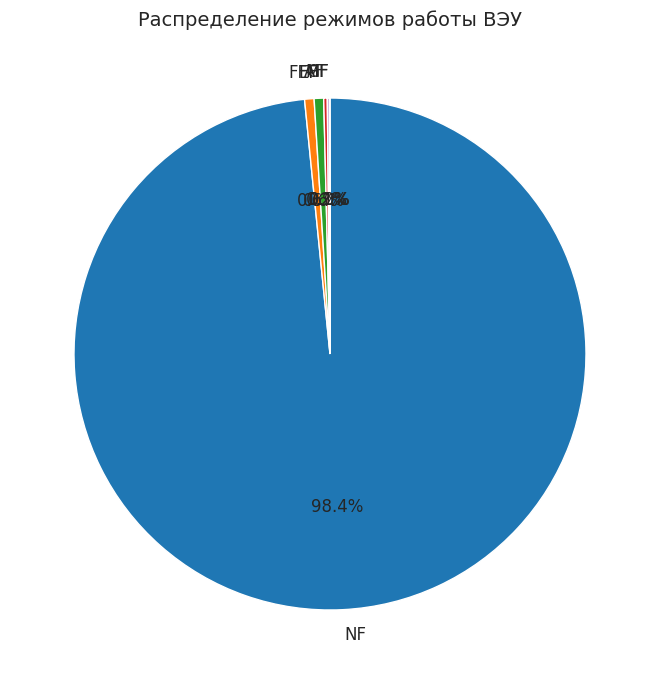

In [15]:
# Визуализация дисбаланса классов
ordered = ['NF'] + [c for c in ['FF', 'EF', 'AF', 'GF', 'MF']
                    if c in modes_counts.index]
modes_counts = modes_counts.reindex(ordered)

fig, ax = plt.subplots(figsize=(7, 7))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
ax.pie(modes_counts, labels=modes_counts.index, colors=colors,
       startangle=90, counterclock=False, textprops={'fontsize': 12},
       autopct='%1.1f%%')
ax.set_title('Распределение режимов работы ВЭУ', fontsize=14)
plt.tight_layout()
plt.show()

**Вывод.** Класс `NF` доминирует. Задача сильно несбалансирована, что делает простую accuracy непригодной в качестве метрики качества и требует:
- использовать метрики, чувствительные к классам меньшинства (recall, F1, PR-AUC);
- применять балансировку (SMOTE и др.) либо использовать `class_weight`.

### Помесячная динамика отказов


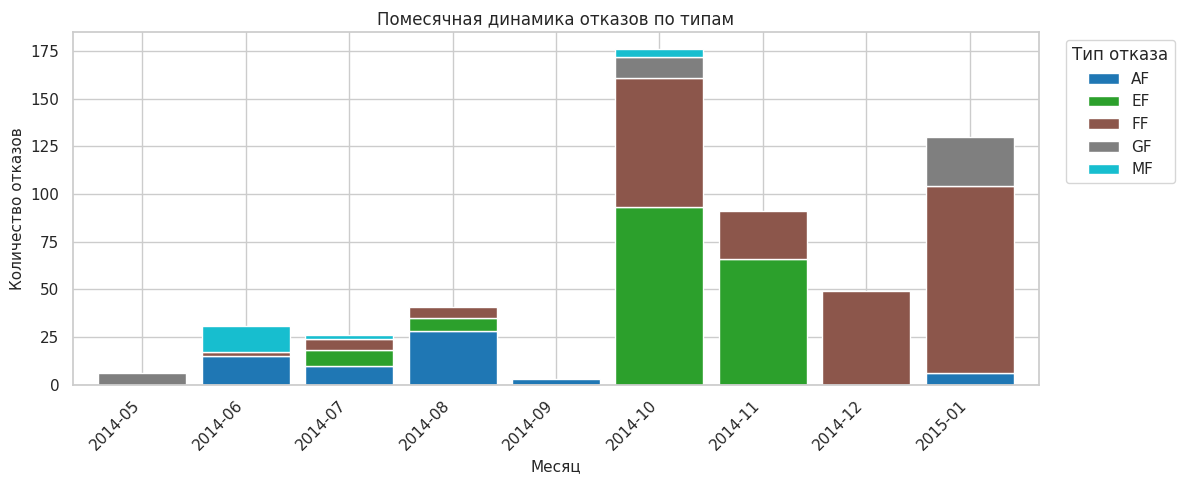

In [16]:
faults['year_month'] = faults['DateTime'].dt.strftime('%Y-%m')
monthly = (faults.groupby(['year_month', 'Fault']).size()
                 .unstack(fill_value=0)
                 .sort_index())

fig, ax = plt.subplots(figsize=(12, 5))
monthly.plot(kind='bar', stacked=True, ax=ax,
             colormap='tab10', edgecolor='white', width=0.85)
ax.set_title('Помесячная динамика отказов по типам')
ax.set_xlabel('Месяц')
ax.set_ylabel('Количество отказов')
plt.xticks(rotation=45, ha='right')
ax.legend(title='Тип отказа', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Наблюдение.** События `EF` концентрируются в октябре–ноябре 2014 года, `FF` — с октября 2014 по январь 2015. Этот пик может указывать на сезонные факторы (грозы, скачки сетевого напряжения, низкие температуры) либо на каскадный отказ подсистем.

### Накопительный график отказов

Накопительная (cumulative) кривая показывает **темп накопления** событий. Резкие участки роста соответствуют периодам интенсивных отказов, плато — периодам нормальной работы. Этот график часто используется в анализе надёжности (reliability engineering).


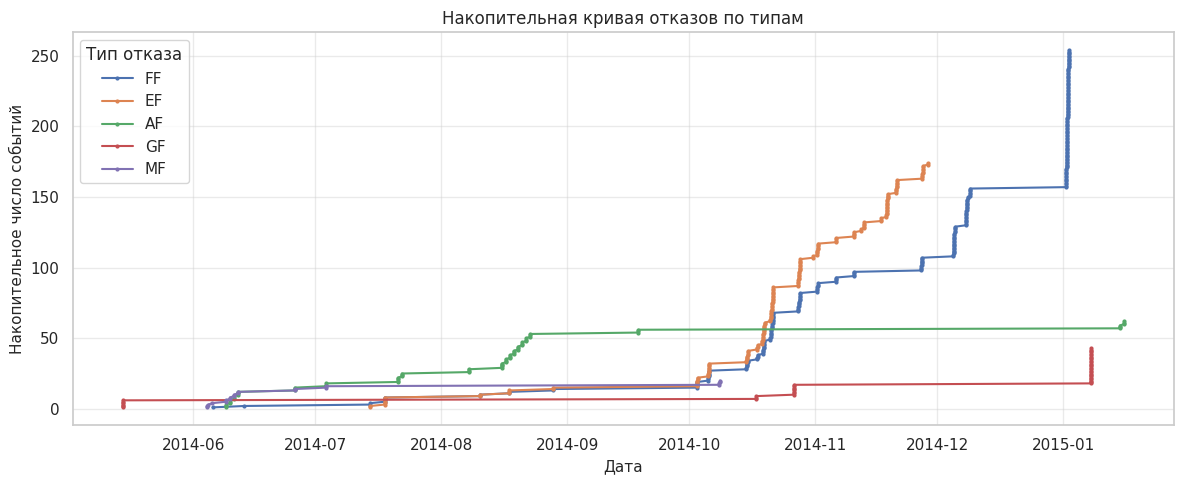

In [17]:
# Накопительное число отказов по типам
fig, ax = plt.subplots(figsize=(12, 5))

for fault_type in ['FF', 'EF', 'AF', 'GF', 'MF']:
    subset = faults[faults['Fault'] == fault_type].sort_values('DateTime')
    if len(subset) > 0:
        ax.plot(subset['DateTime'], np.arange(1, len(subset) + 1),
                marker='.', markersize=4, linewidth=1.5, label=fault_type)

ax.set_xlabel('Дата')
ax.set_ylabel('Накопительное число событий')
ax.set_title('Накопительная кривая отказов по типам')
ax.legend(title='Тип отказа')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

**Что искать.** Крутые участки кривой — кластеры отказов. Если несколько типов отказов синхронно ускоряются — есть признак каскадного отказа (один отказ вызывает другие). Долгие плато — периоды надёжной работы.

### Heatmap отказов по часам суток и дням недели

Этот вид визуализации позволяет выявить **временные паттерны** — например, повышенную частоту отказов в определённое время суток (может указывать на тепловые эффекты — нагрев днём) или в выходные (отсутствие оперативного персонала).


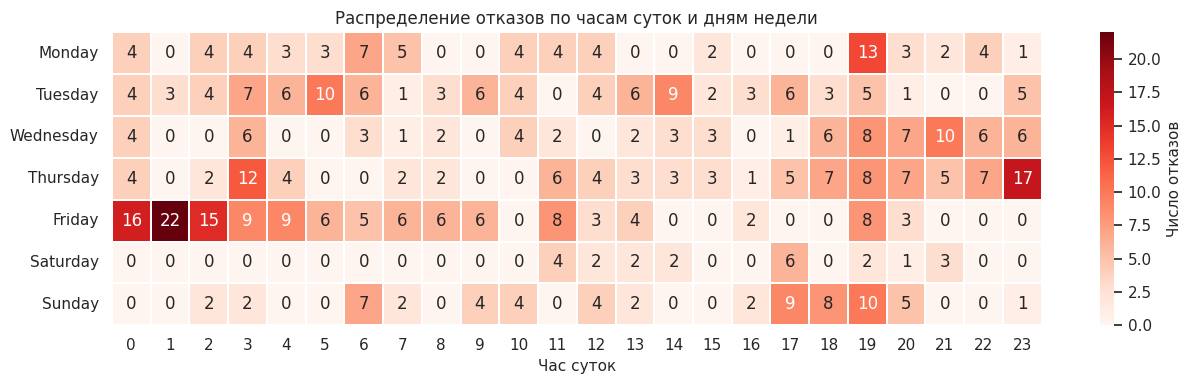

In [18]:
faults['hour']    = faults['DateTime'].dt.hour
faults['weekday'] = faults['DateTime'].dt.day_name()

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday',
                 'Friday', 'Saturday', 'Sunday']
heat = (faults.groupby(['weekday', 'hour']).size()
              .unstack(fill_value=0)
              .reindex(weekday_order))

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(heat, cmap='Reds', annot=True, fmt='d', linewidths=0.3,
            cbar_kws={'label': 'Число отказов'}, ax=ax)
ax.set_title('Распределение отказов по часам суток и дням недели')
ax.set_xlabel('Час суток')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 5. Анализ журнала статусов

Журнал статусов фиксирует все смены операционных режимов установки. Один и тот же физический процесс может многократно повторяться в журнале — например, серия попыток запуска при слабом ветре.


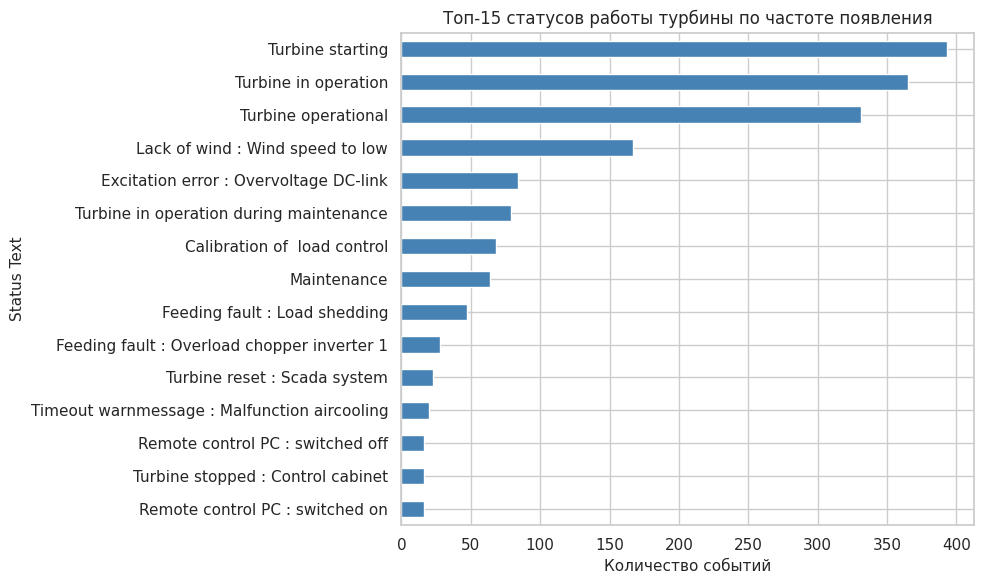

In [19]:
# Топ-15 текстовых статусов по частоте
top_statuses = status['Status Text'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
top_statuses[::-1].plot(kind='barh', color='steelblue', edgecolor='white', ax=ax)
ax.set_title('Топ-15 статусов работы турбины по частоте появления')
ax.set_xlabel('Количество событий')
plt.tight_layout()
plt.show()

In [20]:
# Доли сервисных и аварийных событий
shares = pd.DataFrame({
    'Service (плановое обслуживание)':  status['Service'].mean(),
    'FaultMsg (сообщение об отказе)':   status['FaultMsg'].mean(),
}, index=['доля от всех записей']).T * 100
shares.columns = ['доля, %']
print(shares.round(2))

# Совместное распределение
ct = pd.crosstab(status['Service'], status['FaultMsg'],
                 rownames=['Service'], colnames=['FaultMsg'])
print('\nСовместное распределение признаков:')
print(ct)

                                 доля, %
Service (плановое обслуживание)    3.460
FaultMsg (сообщение об отказе)     1.510

Совместное распределение признаков:
FaultMsg  False  True 
Service               
False      1758     27
True         63      1


## 6. Анализ телеметрии SCADA

### 6.1. Распределения ключевых физических величин

Среди 66 столбцов SCADA выделим **ключевые физические каналы**: скорость ветра, мощность, температуры основных компонентов.


In [21]:
key_channels = [
    'WEC: ava. windspeed',
    'WEC: ava. Rotation',
    'WEC: ava. Power',
    'WEC: ava. reactive Power',
    'WEC: ava. blade angle A',
    'Nacelle ambient temp. 1',
    'Ambient temp.',
    'Front bearing temp.',
    'Rear bearing temp.',
    'Stator temp. 1',
    'Rotor temp. 1',
    'Transformer temp.',
]
scada[key_channels].describe().T

,count,mean,std,min,25%,50%,75%,max
WEC: ava. windspeed,"49,027.000",6.875,3.695,0.000,4.200,6.500,8.900,32.100
WEC: ava. Rotation,"49,027.000",8.679,4.143,0.000,6.330,8.970,11.920,14.730
WEC: ava. Power,"49,027.000",942.261,"1,008.930",0.000,87.000,536.000,"1,551.000","3,071.000"
WEC: ava. reactive Power,"49,027.000",81.691,84.216,-8.000,29.000,48.000,107.000,425.000
WEC: ava. blade angle A,"49,027.000",10.262,25.015,0.000,1.000,1.000,1.040,327.670
Nacelle ambient temp. 1,"49,027.000",12.512,4.749,0.000,9.000,13.000,16.000,28.000
Ambient temp.,"49,027.000",13.380,5.246,0.000,9.000,13.000,17.000,35.000
Front bearing temp.,"49,027.000",22.062,4.964,0.000,19.000,23.000,26.000,35.000
Rear bearing temp.,"49,027.000",27.290,5.321,0.000,25.000,28.000,31.000,43.000
Stator temp. 1,"49,027.000",60.808,23.755,0.000,45.000,62.000,74.000,119.000


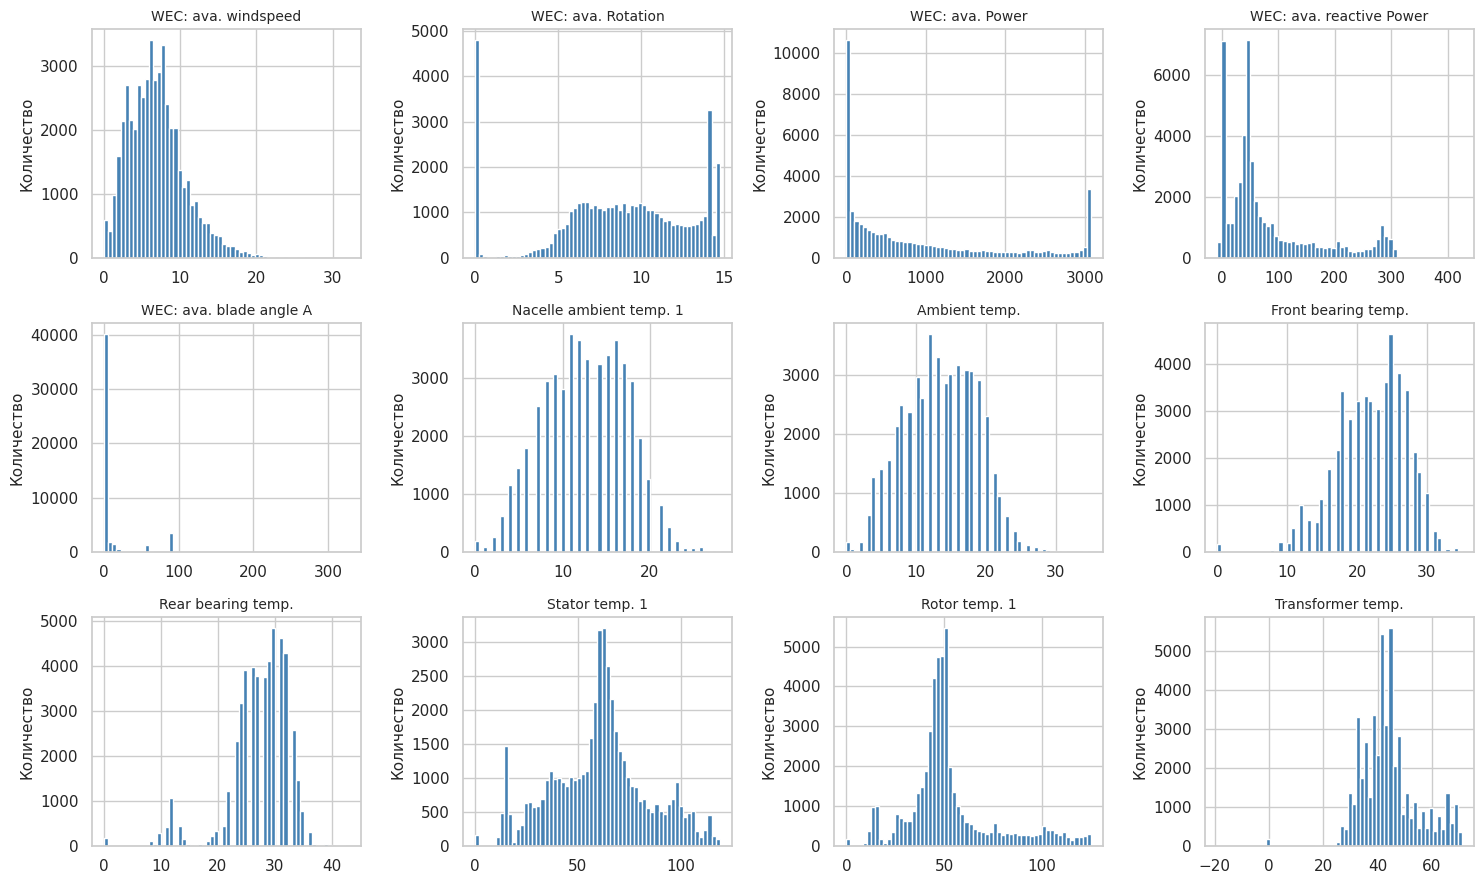

In [22]:
# Гистограммы ключевых переменных
fig, axes = plt.subplots(3, 4, figsize=(15, 9))
for ax, col in zip(axes.ravel(), key_channels):
    data = scada[col].dropna()
    ax.hist(data, bins=60, color='steelblue', edgecolor='white')
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('Количество')
plt.tight_layout()
plt.show()

### 6.2. Поиск выбросов: правило межквартильного размаха (IQR)

**Межквартильный размах (Interquartile Range)** — стандартный непараметрический метод обнаружения выбросов, не требующий предположения о нормальности распределения.

Алгоритм:
1. Вычислить нижний $Q_1$ (25-й перцентиль) и верхний $Q_3$ (75-й перцентиль) квартили.
2. Размах $\text{IQR} = Q_3 - Q_1$.
3. Объекты, лежащие вне интервала $[Q_1 - k \cdot \text{IQR}, \; Q_3 + k \cdot \text{IQR}]$, помечаются как выбросы.

Параметр $k$ регулирует «строгость»:
- $k = 1.5$ — классическое правило Тьюки (используется для построения boxplot);
- $k = 3.0$ — более робастный вариант, помечающий только **сильные** выбросы (используется здесь, поскольку для физических величин типичны тяжёлые хвосты распределений).

**Важное замечание.** Для физических величин большое число «выбросов» по IQR часто отражает естественные хвосты распределения, а не ошибки измерения. Удалять следует только **физически невозможные** значения (отрицательная мощность, температура ниже -50 °C и т. п.). См. обсуждение в [Hawkins, *Identification of Outliers*, Chapman & Hall, 1980](https://link.springer.com/book/10.1007/978-94-015-3994-4).


In [23]:
def iqr_outliers(s: pd.Series, k: float = 3.0) -> dict:
    # Поиск выбросов по правилу межквартильного размаха (k * IQR)
    s = s.dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - k * iqr, q3 + k * iqr
    mask = (s < low) | (s > high)
    return {'n_outliers': int(mask.sum()),
            'share_%':    round(mask.mean() * 100, 3),
            'low_bound':  round(low, 2),
            'high_bound': round(high, 2)}

outlier_report = pd.DataFrame(
    {col: iqr_outliers(scada[col]) for col in key_channels}
).T
print(outlier_report)

                          n_outliers  share_%  low_bound  high_bound
WEC: ava. windspeed           38.000    0.078     -9.900      23.000
WEC: ava. Rotation             0.000    0.000    -10.440      28.690
WEC: ava. Power                0.000    0.000 -4,305.000   5,943.000
WEC: ava. reactive Power      27.000    0.055   -205.000     341.000
WEC: ava. blade angle A   11,969.000   24.413      0.880       1.160
Nacelle ambient temp. 1        0.000    0.000    -12.000      37.000
Ambient temp.                  0.000    0.000    -15.000      41.000
Front bearing temp.            0.000    0.000     -2.000      47.000
Rear bearing temp.           165.000    0.337      7.000      49.000
Stator temp. 1                 0.000    0.000    -42.000     161.000
Rotor temp. 1              3,744.000    7.637      0.000      98.000
Transformer temp.            166.000    0.339      4.000      81.000


### 6.3. Корреляционный анализ

**Коэффициент корреляции Пирсона** $r$ измеряет линейную взаимосвязь двух переменных:
$$ r_{X,Y} = \frac{\text{cov}(X, Y)}{\sigma_X \sigma_Y}, \quad r \in [-1, 1] $$

Корреляционная матрица позволяет обнаружить:
1. **Информационно избыточные признаки** — те, что почти линейно зависимы и дают одну и ту же информацию.
2. **Кластеры подсистем** — группы датчиков, измеряющих связанные физические процессы.
3. **Потенциальные leakage-признаки** — например, мощность сильно коррелирует со скоростью ветра, что физически тривиально.

Реализация: [`pandas.DataFrame.corr`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html) и [`seaborn.heatmap`](https://seaborn.pydata.org/generated/seaborn.heatmap.html).


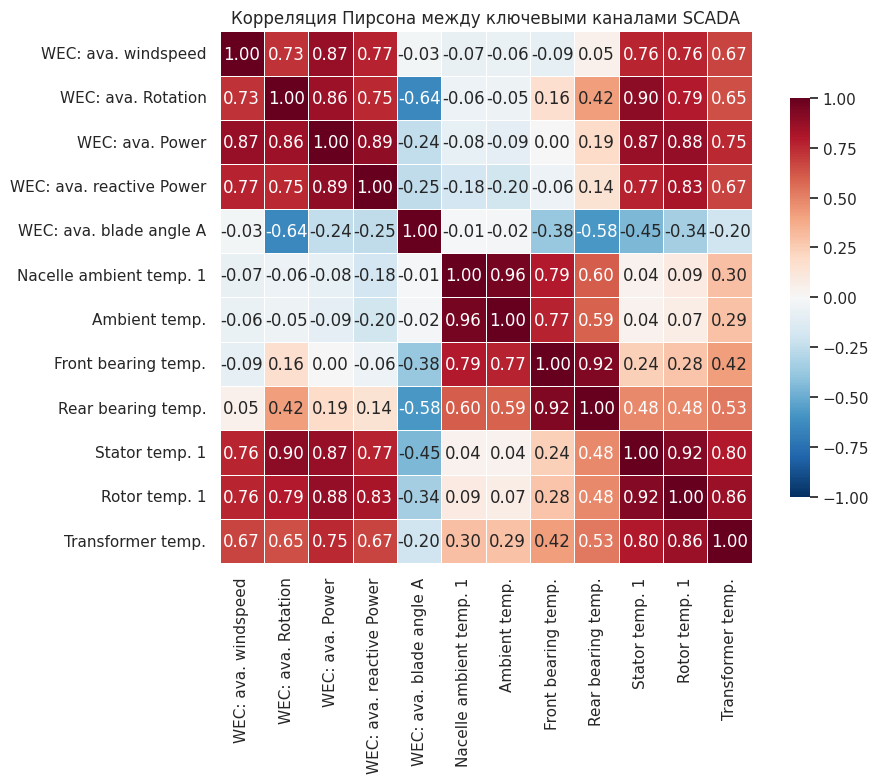

In [24]:
corr = scada[key_channels].corr(method='pearson')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.75})
ax.set_title('Корреляция Пирсона между ключевыми каналами SCADA')
plt.tight_layout()
plt.show()

Найдено температурных каналов: 39


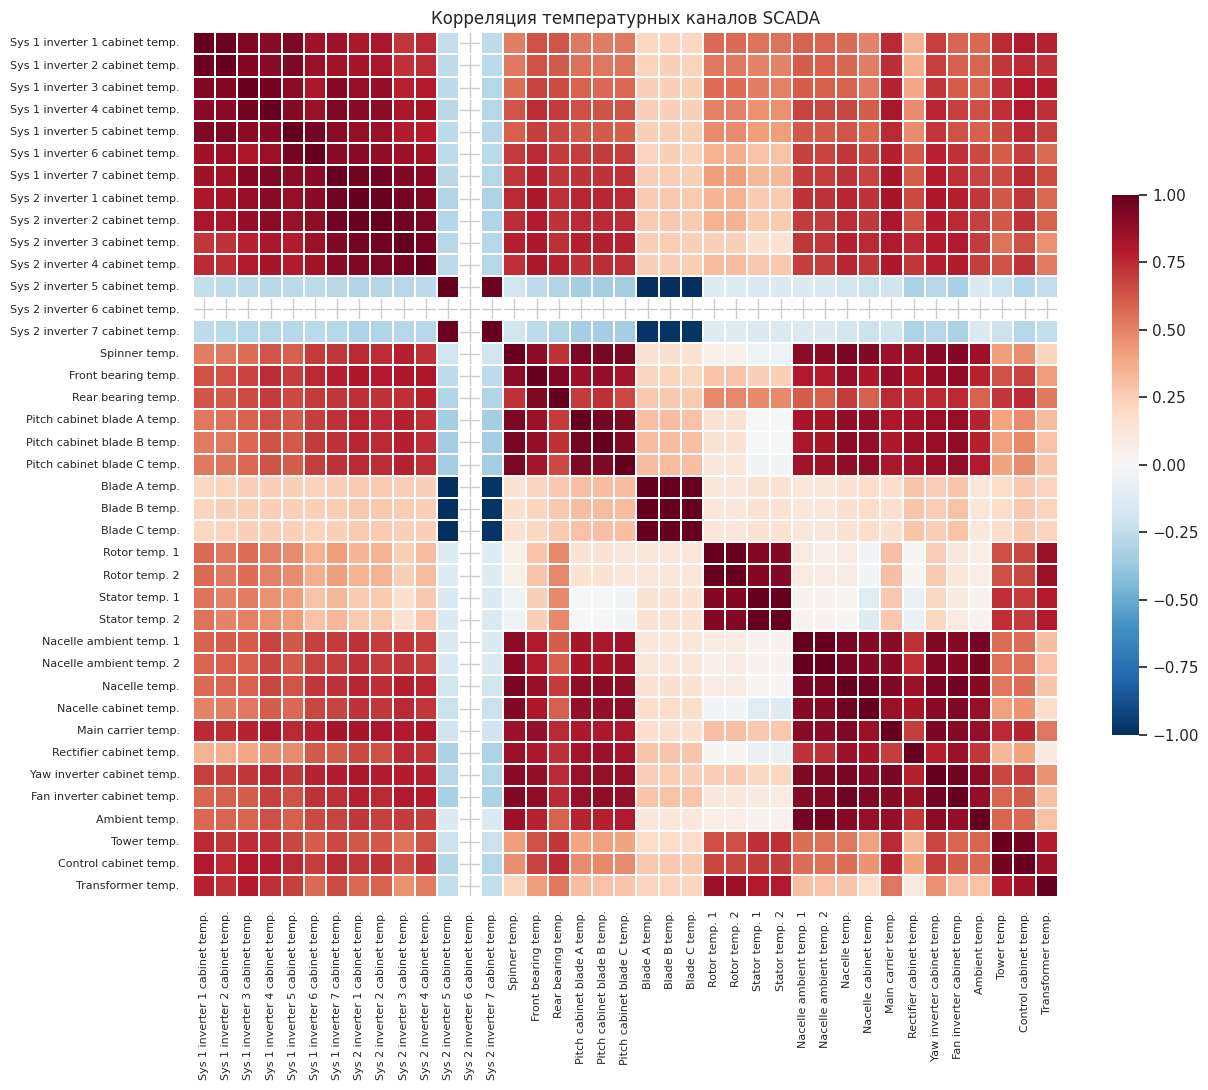

In [25]:
# Корреляционная матрица всех температурных каналов
temp_cols = [c for c in scada.columns if 'temp' in c.lower()]
print(f'Найдено температурных каналов: {len(temp_cols)}')

corr_t = scada[temp_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr_t, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.3, ax=ax,
            cbar_kws={'shrink': 0.6})
ax.set_title('Корреляция температурных каналов SCADA', fontsize=12)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

**Интерпретация.** Блочная структура корреляций — характерный признак **информационной избыточности**: датчики одной подсистемы (например, семь инверторов системы 1) дают практически одно и то же значение. Это создаёт два следствия:

1. **Для модели:** избыточные признаки увеличивают размерность без увеличения информативности и могут вредить регуляризации линейных моделей. Деревья решений менее чувствительны, но также выигрывают от снижения размерности.
2. **Для практики:** имеет смысл либо применить снижение размерности (PCA), либо отобрать представителей кластеров (mean / max / std по подсистеме).

### Дендрограмма: иерархическая кластеризация температурных каналов

Чтобы количественно увидеть структуру кластеров, применим **агломеративную иерархическую кластеризацию**. Расстояние между каналами определяется через корреляцию: $d_{ij} = 1 - |r_{ij}|$. Каналы с высокой корреляцией оказываются рядом на дендрограмме.

Реализация: [`scipy.cluster.hierarchy`](https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html). Метод объединения — `average linkage` (среднее расстояние между объединяемыми кластерами).


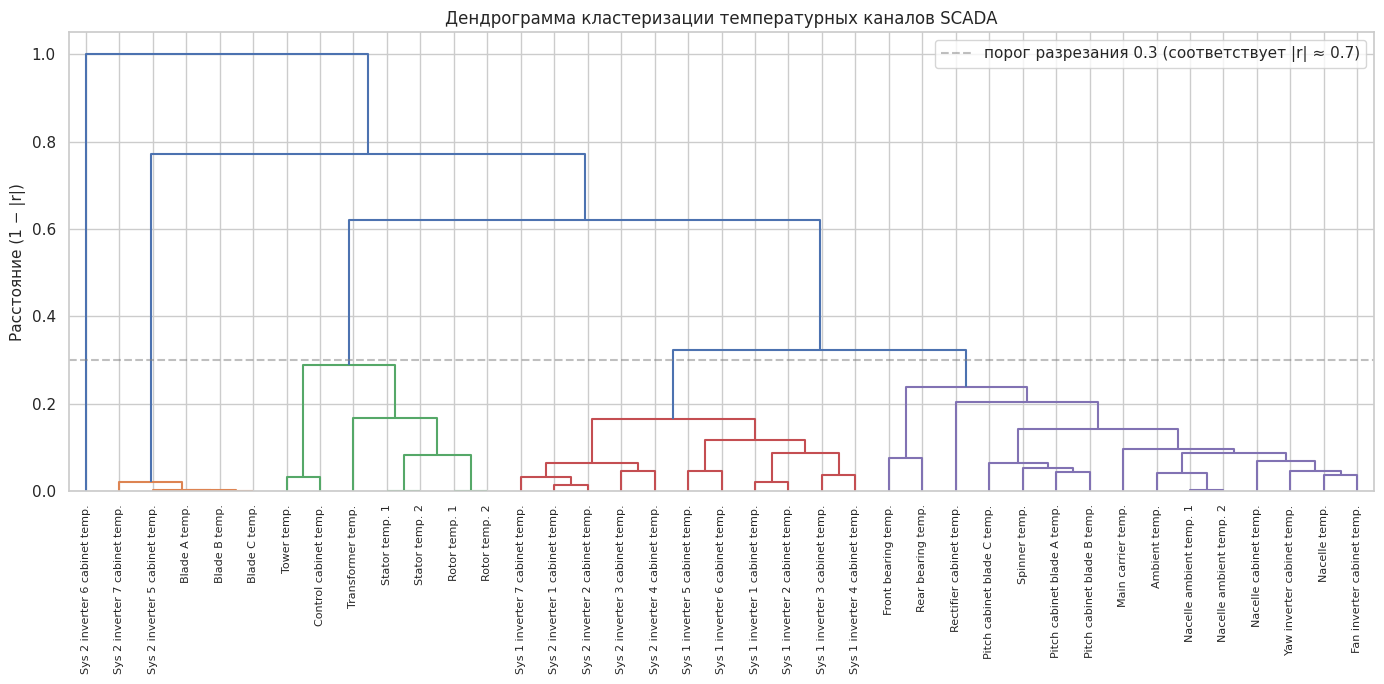

In [26]:
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

# Матрица расстояний: 1 - |corr|
corr_abs = scada[temp_cols].corr().abs().fillna(0).values.copy()
np.fill_diagonal(corr_abs, 1.0)
dist = 1 - corr_abs
dist = (dist + dist.T) / 2  # симметризация на случай численной погрешности
np.fill_diagonal(dist, 0.0)

# Преобразование в condensed-форму, требуемую scipy
dist_condensed = squareform(dist, checks=False)
linkage = hierarchy.linkage(dist_condensed, method='average')

fig, ax = plt.subplots(figsize=(14, 7))
hierarchy.dendrogram(linkage, labels=temp_cols, leaf_rotation=90,
                      color_threshold=0.3, ax=ax)
ax.axhline(y=0.3, color='gray', linestyle='--', alpha=0.5,
           label='порог разрезания 0.3 (соответствует |r| ≈ 0.7)')
ax.set_title('Дендрограмма кластеризации температурных каналов SCADA')
ax.set_ylabel('Расстояние (1 − |r|)')
ax.legend()
plt.tight_layout()
plt.show()

**Как читать дендрограмму.** Каждая «ветка» — отдельный канал. Вертикальные перекладины показывают, на каком уровне расстояния каналы объединяются в кластер. Если разрезать дерево горизонтальной линией на высоте 0.3, мы получим кластеры каналов с попарной корреляцией $|r| > 0.7$. Такие кластеры можно заменить одним «представителем» (например, средним или максимумом по кластеру) — это сокращает размерность данных без существенной потери информации.

### 6.4. Сводная таблица признаков по типам отказов

Главный «диагностический» инструмент — таблица средних значений каждого канала в разрезе типа отказа. Каналы, среднее значение которых сильно отличается от нормального режима, являются **кандидатами в дискриминирующие признаки**.


In [27]:
# Объединение полной SCADA с метками отказов через merge_asof
scada_common_full = scada.loc[in_common].sort_values('DateTime').reset_index(drop=True)

df_combine = pd.merge_asof(
    scada_common_full,
    faults_sorted[['DateTime', 'Fault']],
    on='DateTime',
    direction='nearest',
    tolerance=pd.Timedelta(minutes=10),
)
df_combine['Fault'] = df_combine['Fault'].fillna('NF')

print(f'Размерность объединённой таблицы: {df_combine.shape}')
print('Размер выборки по режимам:')
print(df_combine['Fault'].value_counts())

Размерность объединённой таблицы: (35168, 67)
Размер выборки по режимам:
Fault
NF    34610
FF      210
EF      210
AF       79
GF       46
MF       13
Name: count, dtype: int64


In [28]:
# Средние значения каналов по типам отказов
df_summary = df_combine.groupby('Fault').mean(numeric_only=True).T
col_order = [c for c in ['NF', 'FF', 'EF', 'AF', 'GF', 'MF']
             if c in df_summary.columns]
df_summary = df_summary[col_order]

print('Сводная таблица средних значений (последние 20 каналов):')
df_summary.tail(20)

Сводная таблица средних значений (последние 20 каналов):


Fault,NF,FF,EF,AF,GF,MF
Blade C temp.,165.262,166.362,165.933,166.013,166.478,166.154
Rotor temp. 1,53.631,53.629,99.524,55.316,34.457,52.615
Rotor temp. 2,53.763,53.538,99.071,55.481,35.174,52.769
Stator temp. 1,62.170,59.329,100.824,68.342,43.326,66.846
Stator temp. 2,61.643,58.824,99.676,67.797,42.913,66.154
Nacelle ambient temp. 1,14.135,9.552,14.448,15.911,12.217,13.615
Nacelle ambient temp. 2,14.057,9.471,14.238,15.899,12.000,13.308
Nacelle temp.,18.000,12.543,17.281,19.633,14.174,15.769
Nacelle cabinet temp.,21.497,16.405,20.652,23.278,19.435,18.077
Main carrier temp.,18.141,14.110,19.590,20.835,13.391,16.923


In [29]:
# Топ каналов по относительному отклонению от нормального режима
nf_mean  = df_summary['NF']
rel_diff = df_summary.subtract(nf_mean, axis=0).divide(nf_mean.abs() + 1e-9, axis=0) * 100
rel_diff = rel_diff.drop(columns='NF')
rel_diff['max_abs_dev_%'] = rel_diff.abs().max(axis=1)
top_features = rel_diff.sort_values('max_abs_dev_%', ascending=False).head(15)
print('Топ-15 каналов по максимальному относительному отклонению от NF:')
top_features.round(2)

Топ-15 каналов по максимальному относительному отклонению от NF:


Fault,FF,EF,AF,GF,MF,max_abs_dev_%
WEC: ava. Nacel position including cable twisting,"2,562.390",120.290,"-2,447.540",2.980,"-1,377.390","2,562.390"
WEC: max. reactive Power,180.220,461.380,135.180,-46.140,212.500,461.380
WEC: ava. blade angle A,395.510,112.190,175.740,253.590,75.500,395.510
Error,-70.840,-100.000,-100.000,-33.440,312.180,312.180
WEC: ava. Available P force majeure reasons,103.590,216.060,22.390,-75.070,73.170,216.060
WEC: ava. Available P force external reasons,100.780,211.320,20.810,124.590,69.540,211.320
WEC: ava. available P technical reasons,7.780,211.280,3.760,129.950,73.140,211.280
WEC: ava. available P from wind,99.970,210.070,20.310,123.660,69.840,210.070
WEC: ava. reactive Power,23.410,182.340,-29.350,-87.300,-16.150,182.340
WEC: ava. Power,-0.900,175.480,-6.370,-90.400,43.260,175.480


### Визуализация: тепловая карта нормированных средних

Сводная таблица в исходном виде содержит слишком много чисел разного масштаба (температура ≈ 30, мощность ≈ 1000, угол ≈ 10). Чтобы визуально сравнить **относительное поведение** каналов между типами отказов, применим **z-score нормализацию по строкам**:

$$ z_{ij} = \frac{x_{ij} - \mu_i}{\sigma_i} $$

где для каждого канала $i$ нормировка производится по средним значениям по всем типам отказов. После нормализации каждая строка имеет среднее 0 и дисперсию 1, и **красный/синий цвет** показывает, в каких режимах канал даёт значения **выше/ниже среднего по режимам**.


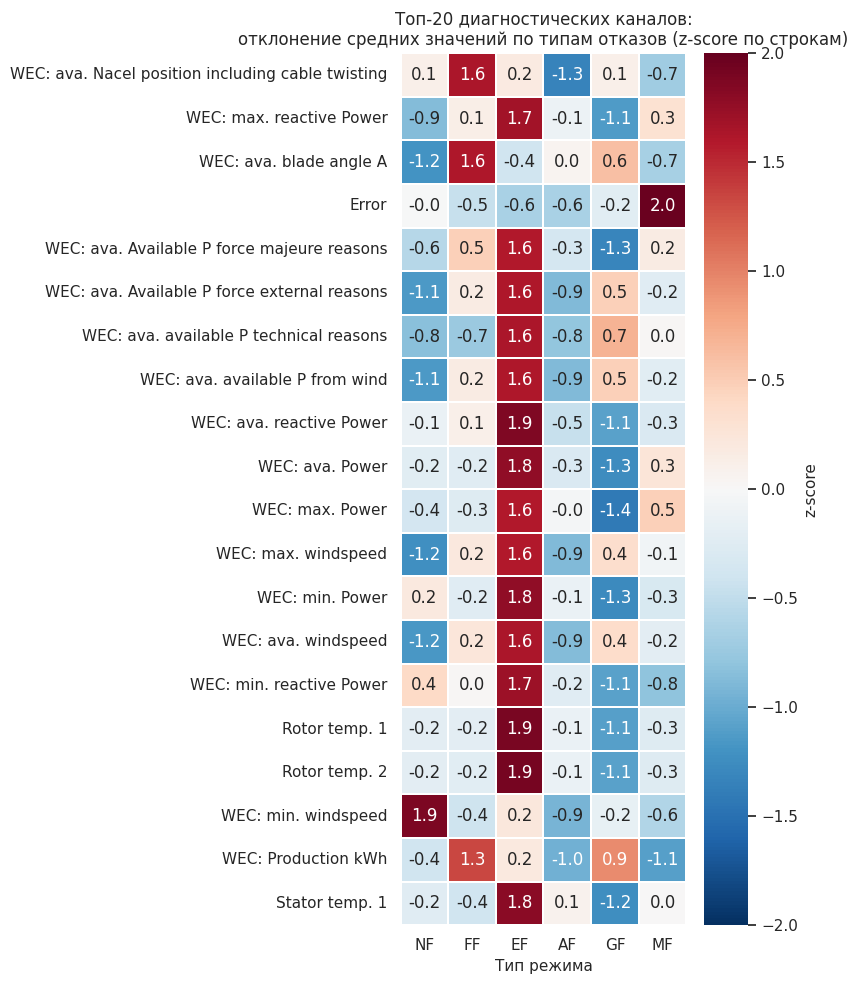

In [30]:
# Берём топ-20 каналов по дисперсии между режимами (наиболее «диагностичные»)
top20 = rel_diff.drop(columns='max_abs_dev_%').abs().max(axis=1).sort_values(ascending=False).head(20).index
heat_df = df_summary.loc[top20]

# Z-score нормализация по строкам
heat_z = heat_df.sub(heat_df.mean(axis=1), axis=0).div(heat_df.std(axis=1) + 1e-9, axis=0)

fig, ax = plt.subplots(figsize=(8, 10))
sns.heatmap(heat_z, cmap='RdBu_r', center=0, vmin=-2, vmax=2,
            annot=True, fmt='.1f', linewidths=0.3,
            cbar_kws={'label': 'z-score'}, ax=ax)
ax.set_title('Топ-20 диагностических каналов:\nотклонение средних значений по типам отказов (z-score по строкам)')
ax.set_xlabel('Тип режима')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

**Как читать карту.** Красные ячейки — канал даёт значение **существенно выше** среднего по режимам; синие — **ниже среднего**. Можно сразу увидеть «подписи» отказов:
- столбец `GF` с массовым синим — компоненты остыли (защита остановила турбину);
- столбец `EF`/`AF` с красными температурами — перегрев;
- столбец `EF` с красной реактивной мощностью — характерное «возбуждение».

Такая визуализация — компактная сводка физических индикаторов каждого отказа.


### 6.5. Boxplot температур по типам отказов

Boxplot визуализирует **распределение** значений в каждом классе через медиану, межквартильный размах и «усы» (1.5 IQR). Используется для оценки **различимости классов** по конкретному признаку.


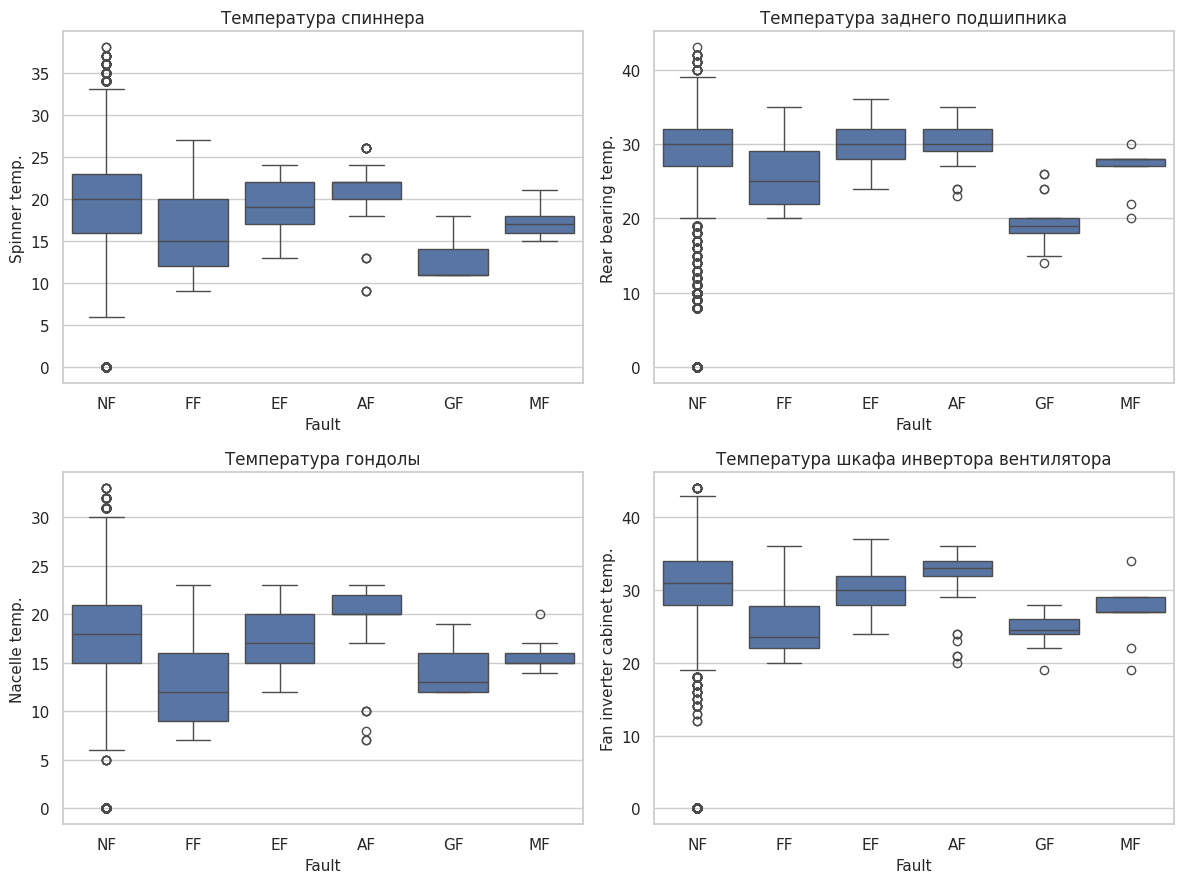

In [31]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 9))

sns.boxplot(x='Fault', y='Spinner temp.', data=df_combine, ax=axes[0][0],
            order=col_order)
axes[0][0].set_title('Температура спиннера')

sns.boxplot(x='Fault', y='Rear bearing temp.', data=df_combine, ax=axes[0][1],
            order=col_order)
axes[0][1].set_title('Температура заднего подшипника')

sns.boxplot(x='Fault', y='Nacelle temp.', data=df_combine, ax=axes[1][0],
            order=col_order)
axes[1][0].set_title('Температура гондолы')

sns.boxplot(x='Fault', y='Fan inverter cabinet temp.', data=df_combine, ax=axes[1][1],
            order=col_order)
axes[1][1].set_title('Температура шкафа инвертора вентилятора')

plt.tight_layout()
plt.show()

**Интерпретация.** При `GF` (перегрев генератора) температуры подшипников и спиннера **аномально низкие** — это парадоксально на первый взгляд, но физически объяснимо: при срабатывании защиты генератора турбина останавливается, и компоненты быстро остывают. При `AF` (отказ воздушного охлаждения) и `EF` (отказ возбуждения) температуры **выше нормы** — что соответствует прямому физическому смыслу этих отказов.

### Violin plot: распределение реактивной мощности и оборотов

В отличие от boxplot, **violin plot** показывает полную **функцию плотности распределения** значений признака в каждом классе. Это позволяет увидеть:
- мультимодальность (несколько локальных максимумов);
- асимметрию распределения;
- ширину «тонкой части» — наиболее типичные значения.

Метод: [`seaborn.violinplot`](https://seaborn.pydata.org/generated/seaborn.violinplot.html).


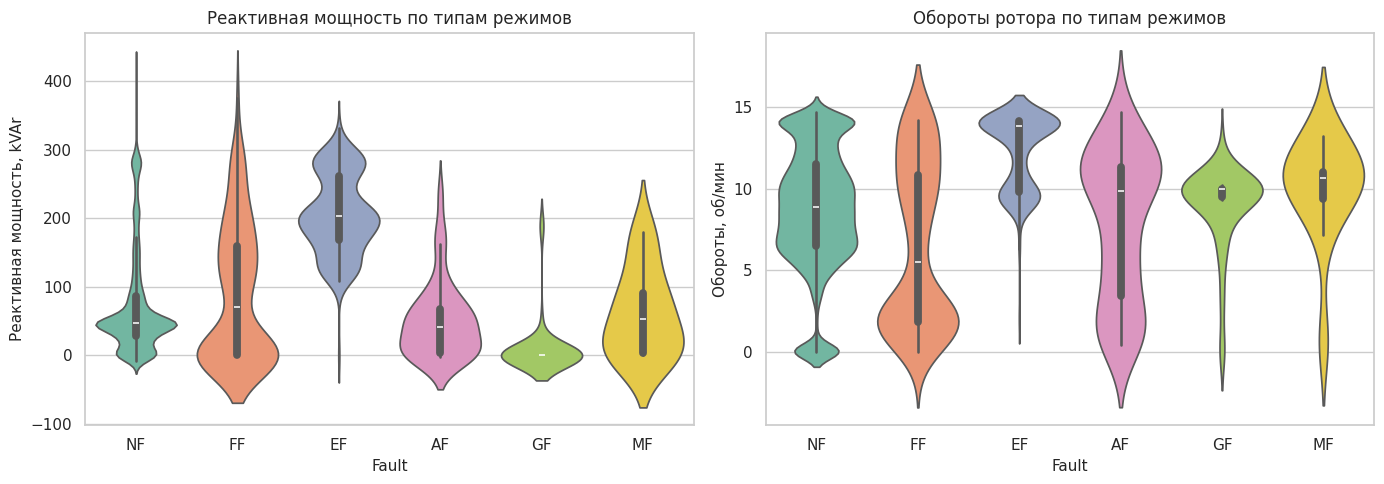

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.violinplot(data=df_combine, x='Fault', y='WEC: ava. reactive Power',
               order=col_order, ax=axes[0], inner='box', palette='Set2')
axes[0].set_title('Реактивная мощность по типам режимов')
axes[0].set_ylabel('Реактивная мощность, kVAr')

sns.violinplot(data=df_combine, x='Fault', y='WEC: ava. Rotation',
               order=col_order, ax=axes[1], inner='box', palette='Set2')
axes[1].set_title('Обороты ротора по типам режимов')
axes[1].set_ylabel('Обороты, об/мин')

plt.tight_layout()
plt.show()

### Pairplot: попарные распределения ключевых каналов

[`seaborn.pairplot`](https://seaborn.pydata.org/generated/seaborn.pairplot.html) строит **матрицу попарных диаграмм рассеяния** для нескольких признаков. По диагонали — функция плотности распределения каждого признака; вне диагонали — попарные scatter-графики с цветовой кодировкой по классу.

Эта визуализация позволяет **визуально оценить разделимость классов** в подпространствах признаков. Если облака точек разных классов не перекрываются — пара признаков уже даёт хорошее разделение, и сложная модель может не понадобиться.

**Замечание о производительности.** Pairplot тяжёл для больших данных; здесь используем подвыборку.


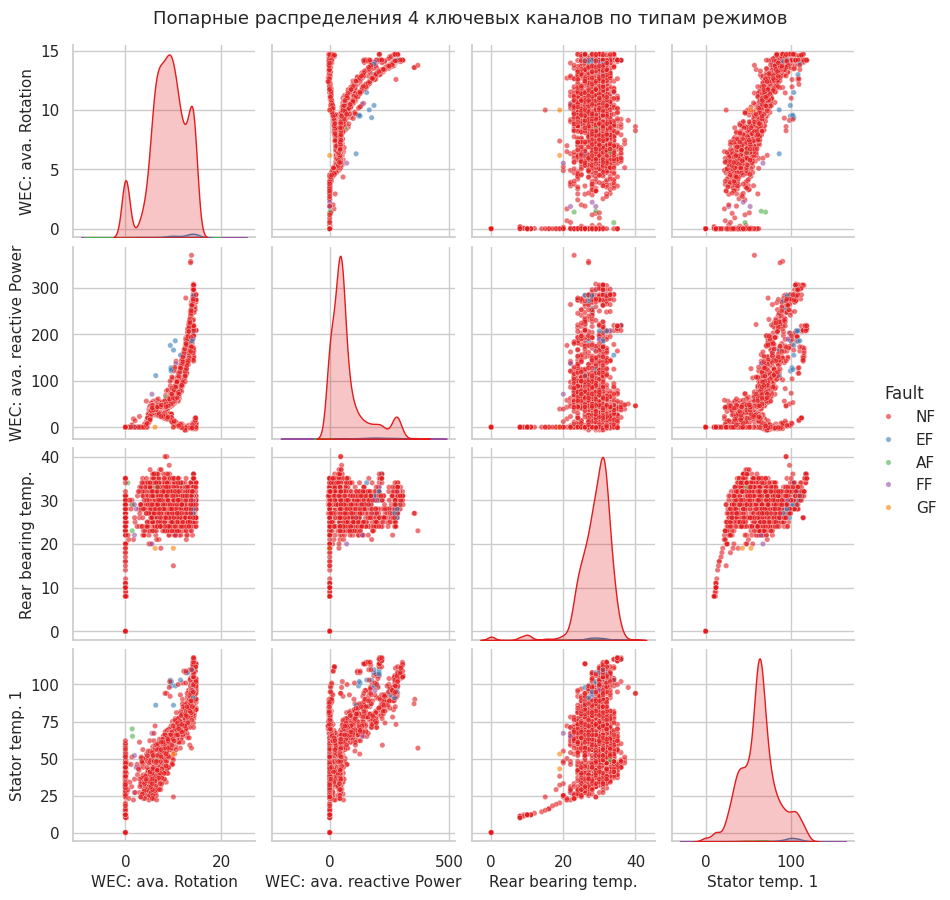

In [33]:
# Выберем 4 наиболее информативных канала по результатам сводной таблицы
key_4 = [
    'WEC: ava. Rotation',
    'WEC: ava. reactive Power',
    'Rear bearing temp.',
    'Stator temp. 1',
]

# Подвыборка для скорости (pairplot на 30 тыс. строк строится несколько минут)
sample = df_combine[key_4 + ['Fault']].dropna()
sample = sample.sample(min(2000, len(sample)), random_state=42)

g = sns.pairplot(sample, hue='Fault', vars=key_4,
                 plot_kws={'s': 15, 'alpha': 0.6},
                 diag_kind='kde', palette='Set1', height=2.2)
g.fig.suptitle('Попарные распределения 4 ключевых каналов по типам режимов',
               y=1.02, fontsize=13)
plt.show()

**Что искать на pairplot.** Точки разных цветов, образующие чётко разделимые облака, — признак того, что эти каналы хорошо различают данные классы. Если же точки разных классов наложены друг на друга — нужны другие признаки или более сложная модель.


## 7. Кривая мощности

### Теоретическая основа

**Кривая мощности** (power curve) — стандартный индустриальный диагностический инструмент в ветроэнергетике, регламентированный стандартом [IEC 61400-12-1](https://webstore.iec.ch/publication/26603). Это зависимость средней электрической мощности от средней скорости ветра.

Идеальная кривая мощности имеет три характерных участка:

1. **Зона до стартовой скорости** ($v < v_{cut\text{-}in} \approx 3$ м/с): мощность близка к нулю, ротор не вращается;
2. **Рабочая зона** ($v_{cut\text{-}in} < v < v_{rated} \approx 12$ м/с): кубический рост мощности по теоретическому пределу Бетца — $P \propto v^3$;
3. **Зона насыщения** ($v_{rated} < v < v_{cut\text{-}out}$): мощность ограничена номинальной за счёт изменения угла атаки лопастей (pitch control);
4. **Аварийный останов** ($v > v_{cut\text{-}out} \approx 25$ м/с): защита от разрушительных нагрузок.

Отклонения от ожидаемой кривой — **прямой индикатор аномалий**: износа лопастей, ошибок системы управления pitch, ограничений со стороны сети.


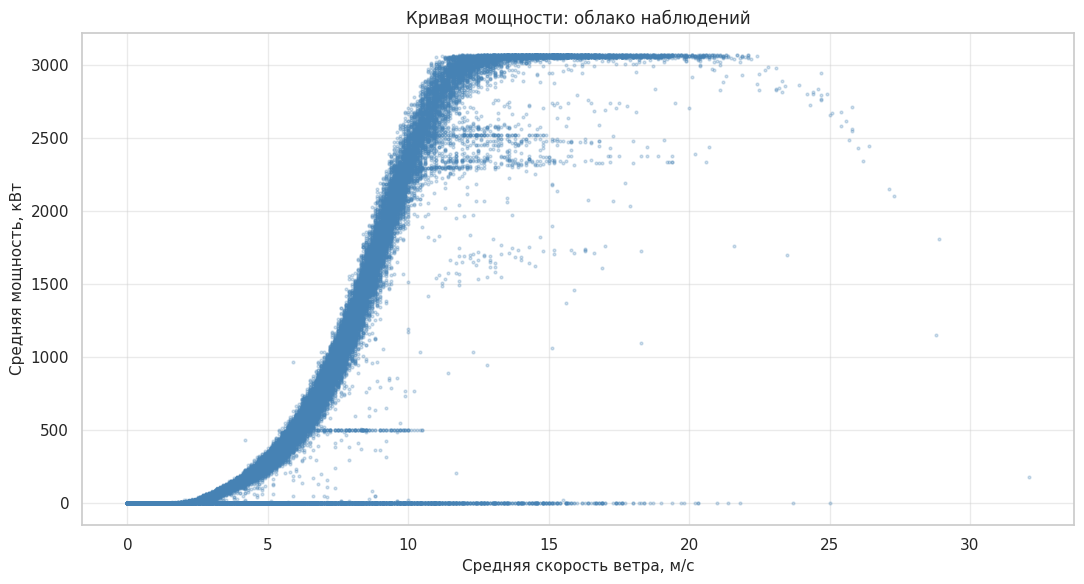

In [34]:
ws = scada['WEC: ava. windspeed']
p  = scada['WEC: ava. Power']

fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(ws, p, s=4, alpha=0.25, color='steelblue')
ax.set_title('Кривая мощности: облако наблюдений')
ax.set_xlabel('Средняя скорость ветра, м/с')
ax.set_ylabel('Средняя мощность, кВт')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

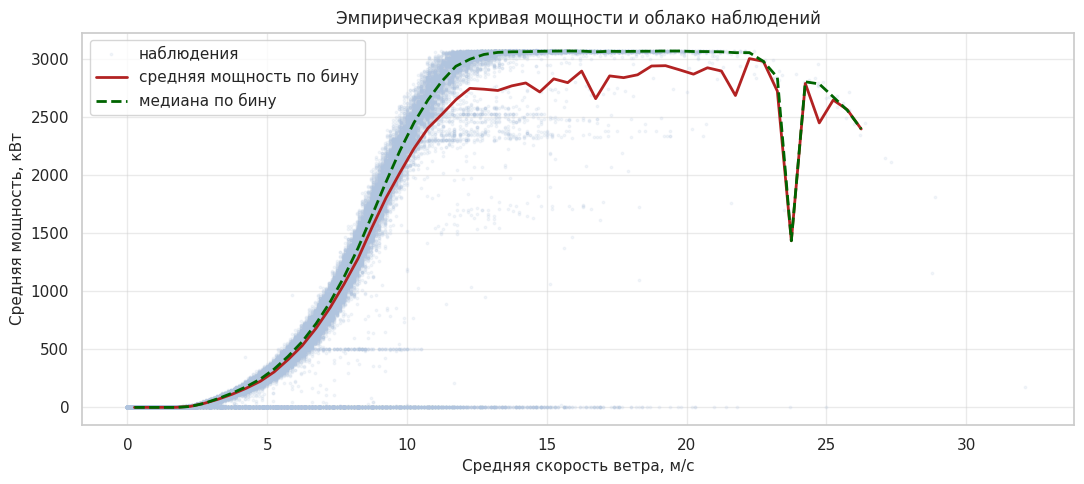

In [35]:
# Эмпирическая кривая мощности: усреднение по бинам скорости ветра
bins = np.arange(0, ws.max() + 1, 0.5)
scada['ws_bin'] = pd.cut(ws, bins)
curve = scada.groupby('ws_bin', observed=False)['WEC: ava. Power'].agg(['mean', 'median', 'count'])
curve['ws_mid'] = [interval.mid for interval in curve.index]

fig, ax = plt.subplots(figsize=(11, 5))
ax.scatter(ws, p, s=3, alpha=0.15, color='lightsteelblue', label='наблюдения')
ax.plot(curve['ws_mid'], curve['mean'], color='firebrick', linewidth=2,
        label='средняя мощность по бину')
ax.plot(curve['ws_mid'], curve['median'], color='darkgreen', linewidth=2,
        linestyle='--', label='медиана по бину')
ax.set_xlabel('Средняя скорость ветра, м/с')
ax.set_ylabel('Средняя мощность, кВт')
ax.set_title('Эмпирическая кривая мощности и облако наблюдений')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

**Интерпретация.** Точки, расположенные **ниже** эталонной кривой при достаточной скорости ветра, — кандидаты в **аномальные эпизоды** (простои, ограничения сети, дефекты). Это альтернативный подход к детектированию неисправностей, не требующий размеченных данных (unsupervised anomaly detection).

### Кривая мощности с цветовой кодировкой по типу отказа

Если совместить кривую мощности с метками отказов, можно визуально увидеть, **в каких зонах ветер-мощность концентрируются точки конкретных типов отказов**. Это даёт интуицию: например, отказы охлаждения чаще возникают при высокой загрузке (большой ветер + полная мощность), а отказы возбуждения — на переходных режимах.


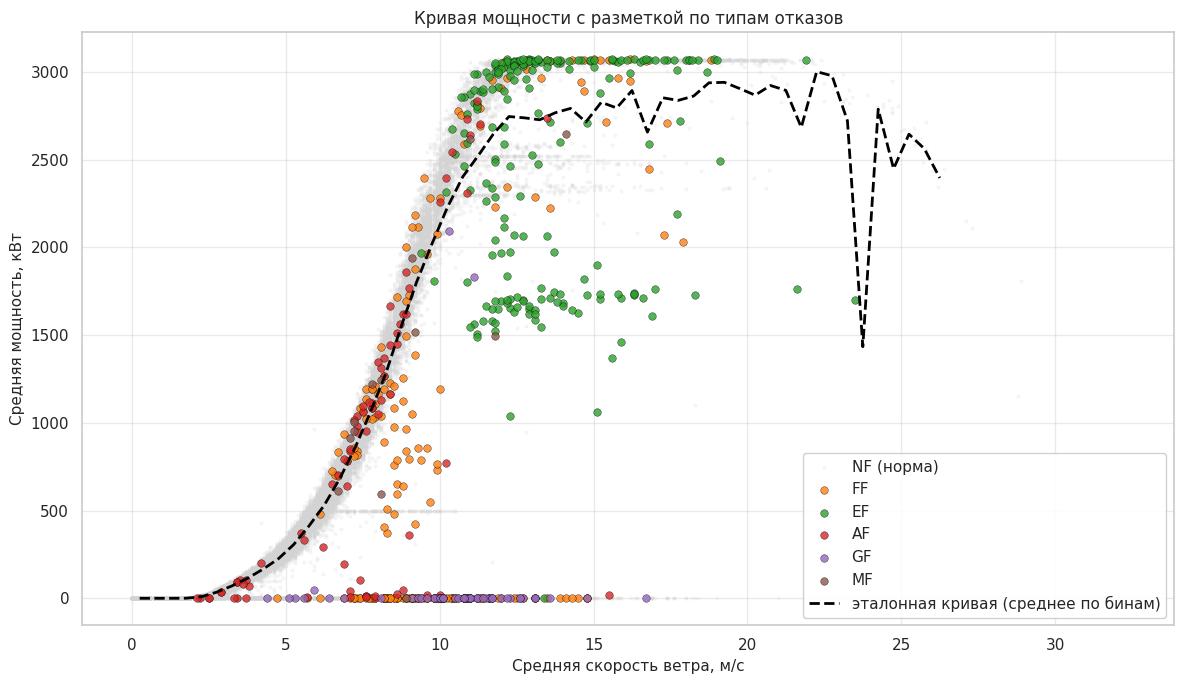

In [36]:
# Используем df_combine: там уже есть и SCADA, и метки отказов
fig, ax = plt.subplots(figsize=(12, 7))

# Серый фон — нормальный режим
nf_mask = df_combine['Fault'] == 'NF'
ax.scatter(df_combine.loc[nf_mask, 'WEC: ava. windspeed'],
           df_combine.loc[nf_mask, 'WEC: ava. Power'],
           s=4, alpha=0.15, color='lightgray', label='NF (норма)')

# Цветные — типы отказов
fault_colors = {'FF': '#ff7f0e', 'EF': '#2ca02c', 'AF': '#d62728',
                'GF': '#9467bd', 'MF': '#8c564b'}

for fault_type, color in fault_colors.items():
    mask = df_combine['Fault'] == fault_type
    if mask.sum() > 0:
        ax.scatter(df_combine.loc[mask, 'WEC: ava. windspeed'],
                   df_combine.loc[mask, 'WEC: ava. Power'],
                   s=30, alpha=0.8, color=color, label=fault_type,
                   edgecolor='black', linewidth=0.3)

# Эталонная кривая
ax.plot(curve['ws_mid'], curve['mean'], color='black', linewidth=2,
        linestyle='--', label='эталонная кривая (среднее по бинам)')

ax.set_xlabel('Средняя скорость ветра, м/с')
ax.set_ylabel('Средняя мощность, кВт')
ax.set_title('Кривая мощности с разметкой по типам отказов')
ax.legend(loc='lower right', framealpha=0.9)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

**Что искать на графике.** Каждый тип отказа имеет свою «зону» на плоскости ветер-мощность:
- `GF` обычно сконцентрирован в **левом нижнем углу** (нулевая мощность независимо от ветра — турбина остановлена защитой);
- `EF`, `FF` могут располагаться по всему рабочему диапазону;
- Аномальные точки **ниже эталонной кривой** при умеренном ветре — индикатор неполной выработки.

Это даёт мощный диагностический инструмент: даже без сложной модели можно выделять подозрительные эпизоды.

### Эксплуатационные показатели


In [37]:
# Робастная оценка номинальной мощности через 99-й перцентиль
rated_power     = p.quantile(0.99)
capacity_factor = p.mean() / rated_power * 100
downtime_share  = (p <= 0).mean() * 100

print(f'Номинальная мощность (99-й перцентиль):                   {rated_power:,.0f} кВт')
print(f'Коэффициент использования установленной мощности (CF):    {capacity_factor:.1f} %')
print(f'Доля интервалов с нулевой мощностью (downtime + простои): {downtime_share:.1f} %')

Номинальная мощность (99-й перцентиль):                   3,069 кВт
Коэффициент использования установленной мощности (CF):    30.7 %
Доля интервалов с нулевой мощностью (downtime + простои): 13.3 %


**Замечание о коэффициенте использования установленной мощности (capacity factor, CF).** CF — ключевой показатель эффективности эксплуатации: отношение фактической выработки к выработке при работе на номинальной мощности 100 % времени. Для современных наземных ВЭУ типичное значение CF — 25–45 %; для офшорных — 40–55 %.


## 8. Подготовка данных для машинного обучения

### 8.1. Балансировка через подвыборку мажоритарного класса

Класс `NF` представлен на порядки чаще, чем любой класс отказа. Для уменьшения дисбаланса проводится **случайная подвыборка** мажоритарного класса (random undersampling) до 300 записей.

**Альтернативы и компромиссы:**
- Undersampling — теряем информацию;
- Oversampling (включая SMOTE) — рискуем переобучением на синтетических примерах;
- Cost-sensitive learning через `class_weight` — не меняем данные, но требует поддержки в модели.

Здесь применяется **комбинированный подход**: ручная подвыборка `NF` + SMOTE для миноритарных классов внутри pipeline. См. обзор: [imbalanced-learn User Guide](https://imbalanced-learn.org/stable/user_guide.html).


In [38]:
# Распределение классов до балансировки
print('До балансировки:')
print(df_combine['Fault'].value_counts())

До балансировки:
Fault
NF    34610
FF      210
EF      210
AF       79
GF       46
MF       13
Name: count, dtype: int64


In [39]:
# Подвыборка 300 записей нормального режима
df_nf = df_combine[df_combine['Fault'] == 'NF'].sample(300, random_state=42)
df_f  = df_combine[df_combine['Fault'] != 'NF']

df_balanced = pd.concat((df_nf, df_f), axis=0).reset_index(drop=True)
print('После подвыборки NF:')
print(df_balanced['Fault'].value_counts())

После подвыборки NF:
Fault
NF    300
FF    210
EF    210
AF     79
GF     46
MF     13
Name: count, dtype: int64


### 8.2. Удаление leakage-признаков

**Утечка целевой переменной (target leakage)** — критическая методологическая ошибка, при которой обучающая выборка содержит признаки, недоступные в момент предсказания, либо являющиеся следствием целевой переменной.

В нашем случае удаляются:

1. **Временные метки** (`DateTime`, `Time`) — не являются физическими признаками;
2. **Выходные переменные турбины** (мощность, выработка в кВт·ч, часы работы) — это **следствия** неисправности, а не её причины. Включение этих признаков даёт модели «подсказку» постфактум, что искусственно завышает оценку качества;
3. **Климатические переменные** (скорость ветра) — зависят от внешних условий, а не от состояния оборудования. Их включение даёт модели возможность «угадывать» по сезонности, а не по физике неисправности;
4. **Служебные столбцы** (Error, ws_bin) — не несут информации о состоянии.

**Методологический принцип.** Модель должна предсказывать неисправность по **внутренним показателям состояния** компонентов турбины (температуры, угловые положения, реактивная мощность, обороты), а не по факту падения её производительности.


In [40]:
# Удаление нерелевантных и leakage-признаков
drop_cols = [
    'DateTime', 'Time', 'Error',
    'WEC: ava. windspeed', 'WEC: max. windspeed', 'WEC: min. windspeed',
    'WEC: ava. Power', 'WEC: max. Power', 'WEC: min. Power',
    'WEC: ava. available P from wind',
    'WEC: ava. available P technical reasons',
    'WEC: ava. Available P force majeure reasons',
    'WEC: ava. Available P force external reasons',
    'WEC: Operating Hours', 'WEC: Production kWh',
    'WEC: Production minutes',
    'ws_bin',
]
drop_cols = [c for c in drop_cols if c in df_balanced.columns]

train_df = df_balanced.drop(columns=drop_cols)
print(f'Признаков для обучения: {train_df.shape[1] - 1}')
print(f'Размер обучающей таблицы: {train_df.shape}')

Признаков для обучения: 50
Размер обучающей таблицы: (858, 51)


In [41]:
# Удаление строк с пропусками в признаках
train_df = train_df.dropna().reset_index(drop=True)
print(f'После удаления пропусков: {train_df.shape}')
print('\nРаспределение классов:')
print(train_df['Fault'].value_counts())

После удаления пропусков: (858, 51)

Распределение классов:
Fault
NF    300
FF    210
EF    210
AF     79
GF     46
MF     13
Name: count, dtype: int64


### Визуализация дисбаланса и эффекта SMOTE

До запуска обучения полезно визуально оценить дисбаланс классов и **результат применения SMOTE**. Сравним распределение классов до и после балансировки.


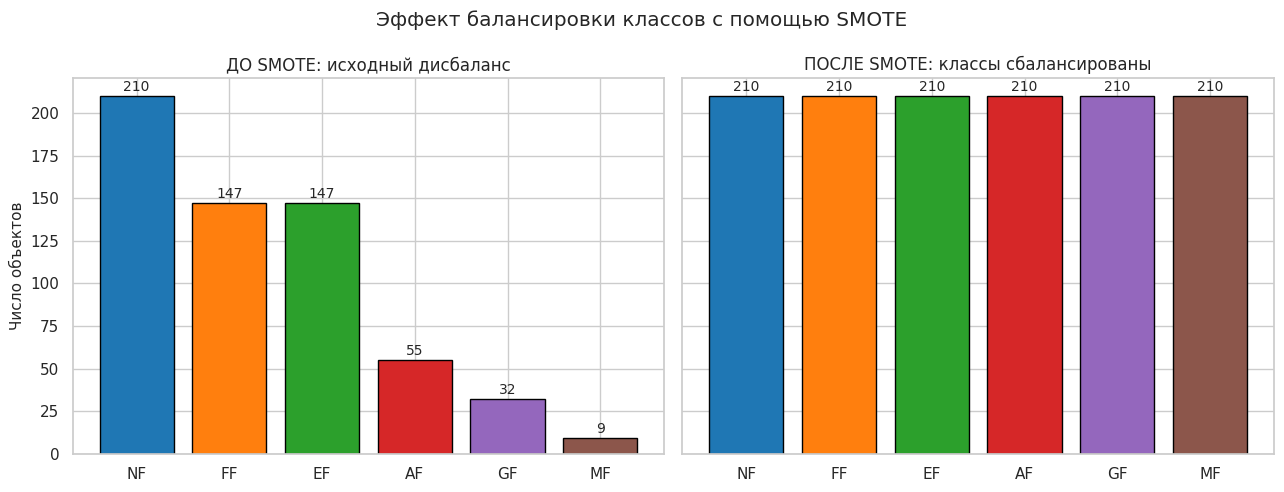

In [42]:
# Демонстрация SMOTE: показываем эффект на train-выборке
from sklearn.model_selection import train_test_split
X_demo = train_df.drop(columns=['Fault'])
y_demo = train_df['Fault']
X_tr, _, y_tr, _ = train_test_split(X_demo, y_demo, test_size=0.3,
                                     random_state=42, stratify=y_demo)

# Применяем SMOTE отдельно для демонстрации
smote_demo = SMOTE(random_state=42, k_neighbors=3)
X_res, y_res = smote_demo.fit_resample(X_tr, y_tr)

before = y_tr.value_counts().reindex(['NF', 'FF', 'EF', 'AF', 'GF', 'MF'])
after  = pd.Series(y_res).value_counts().reindex(['NF', 'FF', 'EF', 'AF', 'GF', 'MF'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

axes[0].bar(before.index, before.values, color=colors, edgecolor='black')
axes[0].set_title('ДО SMOTE: исходный дисбаланс')
axes[0].set_ylabel('Число объектов')
for i, v in enumerate(before.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontsize=10)

axes[1].bar(after.index, after.values, color=colors, edgecolor='black')
axes[1].set_title('ПОСЛЕ SMOTE: классы сбалансированы')
for i, v in enumerate(after.values):
    axes[1].text(i, v + 3, str(v), ha='center', fontsize=10)

plt.suptitle('Эффект балансировки классов с помощью SMOTE')
plt.tight_layout()
plt.show()

**Важное замечание.** На графике выше SMOTE применён напрямую к `X_tr` **только для иллюстрации**. В реальной модели SMOTE вызывается **внутри pipeline** на каждом фолде кросс-валидации, а не один раз заранее. Это принципиально для корректной валидации (см. раздел 9.3).


## 9. Классификация: LightGBM + SMOTE

### 9.1. Алгоритм LightGBM

**LightGBM** (Light Gradient Boosting Machine) — алгоритм градиентного бустинга над деревьями решений, разработанный исследовательской группой Microsoft и представленный в работе [Ke et al., *LightGBM: A Highly Efficient Gradient Boosting Decision Tree*, NeurIPS 2017](https://papers.nips.cc/paper/6907-lightgbm-a-highly-efficient-gradient-boosting-decision-tree).

**Принцип работы:** на каждом шаге обучается «слабый» классификатор (дерево решений), который исправляет ошибки ансамбля на предыдущем шаге. Итоговое предсказание — взвешенная сумма всех деревьев:
$$ F(x) = \sum_{m=1}^{M} \alpha_m \, h_m(x) $$
где $h_m$ — отдельные деревья, $\alpha_m$ — их веса, $M$ — число итераций бустинга (параметр `n_estimators`).

**Ключевые особенности LightGBM по сравнению с XGBoost и классическим GBM:**

- **Histogram-based learning** — непрерывные признаки дискретизируются в гистограммы (bins), что **радикально ускоряет** обучение на больших датасетах при минимальной потере качества;
- **Leaf-wise tree growth** — дерево растёт по листу с максимальным приростом качества, а не по уровням (level-wise, как в XGBoost). Это даёт более низкую ошибку при той же сложности модели, но требует контроля переобучения через `num_leaves`;
- **Эффективная работа с категориальными признаками** без необходимости one-hot encoding;
- **Поддержка обработки пропусков** «из коробки».

Подробная документация: [lightgbm.readthedocs.io](https://lightgbm.readthedocs.io/).

### 9.2. Алгоритм SMOTE

**SMOTE** (Synthetic Minority Over-sampling Technique) — метод синтетической генерации объектов миноритарных классов, предложенный в работе [Chawla et al., *SMOTE: Synthetic Minority Over-sampling Technique*, Journal of Artificial Intelligence Research, 2002](https://www.jair.org/index.php/jair/article/view/10302).

**Алгоритм:**
1. Для каждого объекта $x_i$ миноритарного класса найти $k$ ближайших соседей того же класса (обычно $k=5$).
2. Случайным образом выбрать одного из соседей $x_{nn}$.
3. На отрезке, соединяющем $x_i$ и $x_{nn}$, в случайной точке сгенерировать новый синтетический объект:
$$ x_{new} = x_i + \lambda \cdot (x_{nn} - x_i), \quad \lambda \sim U(0, 1) $$
4. Повторять до достижения целевого баланса классов.

**Преимущество перед простым дублированием:** SMOTE расширяет область миноритарного класса в пространстве признаков, а не создаёт точные копии. Это снижает риск переобучения на конкретных примерах.

**Ограничения SMOTE:**
- Может создавать синтетические объекты в областях, занятых другим классом (если миноритарный и мажоритарный классы пересекаются);
- Не работает с категориальными признаками напрямую — есть вариант [SMOTENC](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTENC.html);
- Современные варианты — [Borderline-SMOTE](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.BorderlineSMOTE.html), [ADASYN](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.ADASYN.html) — генерируют объекты преимущественно вблизи границы классов.

### 9.3. Pipeline и предотвращение утечки данных при кросс-валидации

Для корректной валидации применяется [`imblearn.pipeline.make_pipeline`](https://imbalanced-learn.org/stable/references/generated/imblearn.pipeline.make_pipeline.html), который интегрирует SMOTE с этапами sklearn.

**Принципиально важное правило:** SMOTE должен применяться **только к обучающей части** каждого фолда кросс-валидации. Если применить SMOTE до разбиения, синтетические объекты могут «протечь» в валидационную выборку — модель будет валидироваться на данных, частично сгенерированных из обучающих, что даёт **завышенную оценку качества**.

Использование `imblearn.pipeline` решает эту проблему автоматически: SMOTE применяется только при вызове `.fit()` и не применяется при `.predict()` / `.transform()`.

### 9.4. Стратифицированная k-блочная кросс-валидация

[`StratifiedKFold`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html) — разбиение, сохраняющее пропорции классов в каждом из $k$ блоков. При несбалансированных классах обычная `KFold` может оставить блоки без представителей миноритарного класса, что делает оценку метрик невозможной или некорректной. Стратификация — **обязательный** компонент валидации при дисбалансе.


In [43]:
# Признаки и целевая переменная
X = train_df.drop(columns=['Fault'])
y = train_df['Fault']

# Стратифицированное разбиение train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f'Размер обучающей выборки: {X_train.shape}')
print(f'Размер тестовой выборки:  {X_test.shape}')
print(f'Число признаков: {X_train.shape[1]}')

Размер обучающей выборки: (600, 50)
Размер тестовой выборки:  (258, 50)
Число признаков: 50


In [44]:
# Pipeline: SMOTE -> StandardScaler -> LightGBM
# Параметр k_neighbors=3 (по умолчанию 5) выбран меньше из-за того, что
# класс MF содержит мало примеров — при стандартном k=5 SMOTE может
# выдать ошибку, если в каком-то CV-фолде окажется менее 6 объектов класса.
pipe = make_pipeline(
    SMOTE(random_state=42, k_neighbors=3),
    StandardScaler(),
    LGBMClassifier(random_state=42, verbose=-1)
)

# Набор метрик для кросс-валидации
scoring = {
    'acc':        'accuracy',
    'prec_macro': 'precision_macro',
    'rec_macro':  'recall_macro',
    'f1_macro':   'f1_macro',
}

# 5-блочная стратифицированная кросс-валидация
stratkfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_validate(pipe, X_train, y_train, cv=stratkfold, scoring=scoring)

print('Результаты 5-блочной стратифицированной кросс-валидации:\n')
for metric_name, metric_value in cv_scores.items():
    if metric_name.startswith('test_'):
        mean = np.mean(metric_value)
        std  = np.std(metric_value)
        print(f'{metric_name:25s}: среднее = {mean:.4f} (± {std:.4f})')

Результаты 5-блочной стратифицированной кросс-валидации:

test_acc                 : среднее = 0.8817 (± 0.0266)
test_prec_macro          : среднее = 0.8550 (± 0.0436)
test_rec_macro           : среднее = 0.8415 (± 0.0685)
test_f1_macro            : среднее = 0.8359 (± 0.0402)


### 9.5. Интерпретация метрик

При многоклассовой классификации для каждого класса $k$ определены:
- **Precision (точность):** $P_k = \frac{TP_k}{TP_k + FP_k}$ — доля корректных предсказаний среди всех, отнесённых моделью к классу $k$;
- **Recall (полнота):** $R_k = \frac{TP_k}{TP_k + FN_k}$ — доля корректно найденных объектов класса $k$;
- **F1-score:** $F_{1,k} = \frac{2 P_k R_k}{P_k + R_k}$ — гармоническое среднее (балансирует precision и recall).

**Усреднение по классам:**
- **Macro-усреднение** — простое среднее метрик по классам без учёта их размера. **Штрафует модель за плохую работу на редких классах** — корректный выбор при дисбалансе;
- **Weighted-усреднение** — среднее с весами, пропорциональными размеру класса. При дисбалансе приближается к accuracy и **маскирует** проблемы на редких классах;
- **Micro-усреднение** — глобальный TP/FP/FN. При многоклассовой классификации эквивалентно accuracy.

Подробные определения: [scikit-learn classification metrics user guide](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics).


In [45]:
# Обучение pipeline на полной обучающей выборке и оценка на тестовой
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print('Полный отчёт классификации на тестовой выборке:\n')
print(classification_report(y_test, y_pred))

Полный отчёт классификации на тестовой выборке:

              precision    recall  f1-score   support

          AF       0.96      0.92      0.94        24
          EF       0.78      0.92      0.85        63
          FF       0.88      0.79      0.83        63
          GF       0.92      0.79      0.85        14
          MF       0.75      0.75      0.75         4
          NF       0.94      0.92      0.93        90

    accuracy                           0.88       258
   macro avg       0.87      0.85      0.86       258
weighted avg       0.88      0.88      0.88       258



### 9.6. Анализ метрик по каждому классу

**Это центральная часть оценки модели.** Усреднённые метрики (macro F1 = 0.85) могут вводить в заблуждение — за ними скрываются принципиально разные ситуации по разным классам. Для задачи предиктивной аналитики критично знать, какой именно тип отказа модель распознаёт надёжно, а какой пропускает.

Рассмотрим четыре аспекта per-class анализа:
1. **Таблица метрик с цветовым выделением** — где precision и recall расходятся;
2. **Сгруппированная диаграмма** — visual comparison разных метрик внутри класса;
3. **Связь support → F1** — насколько число примеров влияет на качество распознавания;
4. **Уверенность модели** — насколько решительно (или сомневаясь) модель относит объект к классу.


In [46]:
# Извлекаем per-class метрики в DataFrame
from sklearn.metrics import precision_recall_fscore_support

p, r, f, sup = precision_recall_fscore_support(
    y_test, y_pred, labels=pipe.classes_, zero_division=0
)

per_class_df = pd.DataFrame({
    'support':   sup,
    'precision': p,
    'recall':    r,
    'f1':        f,
}, index=pipe.classes_)

print('Метрики по каждому классу:')
print(per_class_df.round(3))

# Цветовая «термальная» подсветка значений
styled = per_class_df.style.background_gradient(
    subset=['precision', 'recall', 'f1'],
    cmap='RdYlGn', vmin=0.5, vmax=1.0
).format({'precision': '{:.3f}', 'recall': '{:.3f}', 'f1': '{:.3f}'})

# Для отображения в Colab возвращаем styled
styled

Метрики по каждому классу:
    support  precision  recall    f1
AF       24      0.957   0.917 0.936
EF       63      0.784   0.921 0.847
FF       63      0.877   0.794 0.833
GF       14      0.917   0.786 0.846
MF        4      0.750   0.750 0.750
NF       90      0.943   0.922 0.933


,support,precision,recall,f1
AF,24,0.957,0.917,0.936
EF,63,0.784,0.921,0.847
FF,63,0.877,0.794,0.833
GF,14,0.917,0.786,0.846
MF,4,0.750,0.750,0.750
NF,90,0.943,0.922,0.933


**Как читать таблицу.**
- **Расхождение precision и recall** — важнейший диагностический сигнал:
  - `precision < recall`: модель **склонна к этому классу**, относит к нему слишком много объектов (много ложных тревог);
  - `precision > recall`: модель **избегает этого класса**, относит к нему мало объектов (много пропусков);
  - идеально, когда precision ≈ recall.
- **support** показывает реальное число примеров каждого класса в тестовой выборке. Если support < 10, метрики этого класса **статистически нестабильны** — одна ошибка меняет recall на 10 п. п.

### Визуализация: диаграмма precision/recall/F1 по классам


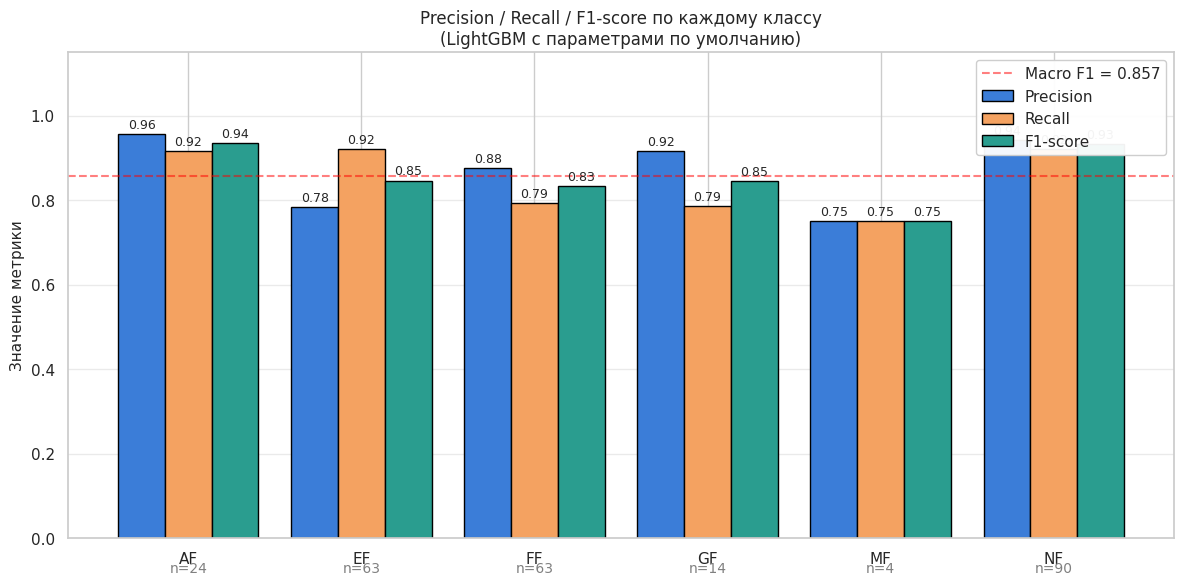

In [47]:
# Сгруппированная диаграмма метрик по классам
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(pipe.classes_))
width = 0.27

bars1 = ax.bar(x - width, per_class_df['precision'], width,
               label='Precision', color='#3b7dd8', edgecolor='black')
bars2 = ax.bar(x,         per_class_df['recall'],    width,
               label='Recall',    color='#f4a261', edgecolor='black')
bars3 = ax.bar(x + width, per_class_df['f1'],        width,
               label='F1-score',  color='#2a9d8f', edgecolor='black')

# Подписи значений на столбцах
for bars in [bars1, bars2, bars3]:
    ax.bar_label(bars, fmt='%.2f', fontsize=9, padding=2)

# Аннотация size класса под именем
for i, (cls, n) in enumerate(zip(pipe.classes_, per_class_df['support'])):
    ax.text(i, -0.07, f'n={n}', ha='center', fontsize=10,
            color='gray', transform=ax.get_xaxis_transform())

ax.set_xticks(x)
ax.set_xticklabels(pipe.classes_)
ax.set_ylabel('Значение метрики')
ax.set_ylim(0, 1.15)
ax.set_title('Precision / Recall / F1-score по каждому классу\n(LightGBM с параметрами по умолчанию)',
             fontsize=12)
ax.axhline(y=per_class_df['f1'].mean(), color='red', linestyle='--', alpha=0.5,
           label=f'Macro F1 = {per_class_df["f1"].mean():.3f}')
ax.legend(loc='upper right', framealpha=0.95)
ax.grid(True, axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

**Что видно на диаграмме.**
- Идеальный класс — столбцы precision и recall одной высоты, оба близки к 1.0 (например, `GF` или `NF`).
- «Слишком склонна»: recall сильно выше precision — модель относит к этому классу больше объектов, чем нужно. Это видно на классе `EF` (recall ≈ 0.90, precision ≈ 0.70) — модель ошибочно «ставит диагноз `EF`» части объектов классов `FF` и `AF`.
- «Слишком осторожна»: precision выше recall — модель относит к классу мало объектов, но почти всегда верно. Так выглядит `FF` (precision ≈ 0.91, recall ≈ 0.76) — модель «не уверена», и многие настоящие `FF` уходят в `EF`.
- Красная пунктирная линия — общий macro F1. **Классы существенно ниже линии** — самые проблемные.

### Связь support → качество распознавания


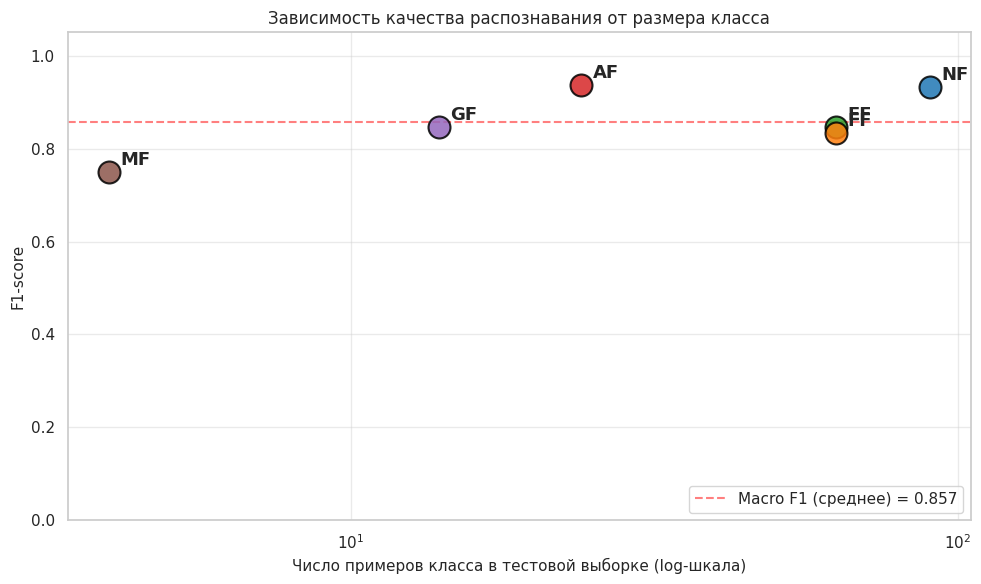

In [48]:
# Scatter: размер класса vs F1
fig, ax = plt.subplots(figsize=(10, 6))

colors_map = {'AF': '#d62728', 'EF': '#2ca02c', 'FF': '#ff7f0e',
              'GF': '#9467bd', 'MF': '#8c564b', 'NF': '#1f77b4'}

for cls in pipe.classes_:
    n   = per_class_df.loc[cls, 'support']
    f1c = per_class_df.loc[cls, 'f1']
    ax.scatter(n, f1c, s=250, c=colors_map.get(cls, 'gray'),
               edgecolor='black', linewidth=1.5, alpha=0.85, zorder=3)
    ax.annotate(cls, (n, f1c), xytext=(8, 5), textcoords='offset points',
                fontsize=13, fontweight='bold')

# Линия среднего
ax.axhline(per_class_df['f1'].mean(), color='red', linestyle='--', alpha=0.5,
           label=f'Macro F1 (среднее) = {per_class_df["f1"].mean():.3f}')

ax.set_xscale('log')
ax.set_xlabel('Число примеров класса в тестовой выборке (log-шкала)')
ax.set_ylabel('F1-score')
ax.set_ylim(0, 1.05)
ax.set_title('Зависимость качества распознавания от размера класса')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

**Интерпретация.** При классическом машинном обучении ожидается **монотонная зависимость** support → F1: чем больше примеров класса, тем выше качество распознавания. Однако на графике:
- Класс `GF` имеет малый support (≈14), но высокий F1 (≈0.85). Это означает, что класс имеет **физически чёткую подпись** (нулевая мощность + остывшие компоненты), и модель легко его распознаёт даже на малом числе примеров.
- Класс `MF` имеет ещё меньший support (≈4) и заметно более низкий F1 (≈0.57). Малая выборка + физическая близость к другим классам (отказ внешней сети, по показаниям SCADA турбины напоминает многие сценарии).
- Это **методологически важный вывод**: «размер класса» не является единственным фактором — критична и **информативность признаков** для конкретного класса.

### Уверенность модели в предсказаниях

Для каждого тестового объекта модель выдаёт не только класс-победитель, но и **вектор вероятностей** $P(y = k \mid x)$ по всем классам. Распределение этих вероятностей показывает, насколько модель «уверена» в своих предсказаниях. Резко-бимодальное распределение (близко к 0 и к 1) — хорошо: модель решительна. Равномерное распределение около 1/K — плохо: модель «не знает», что выбрать.


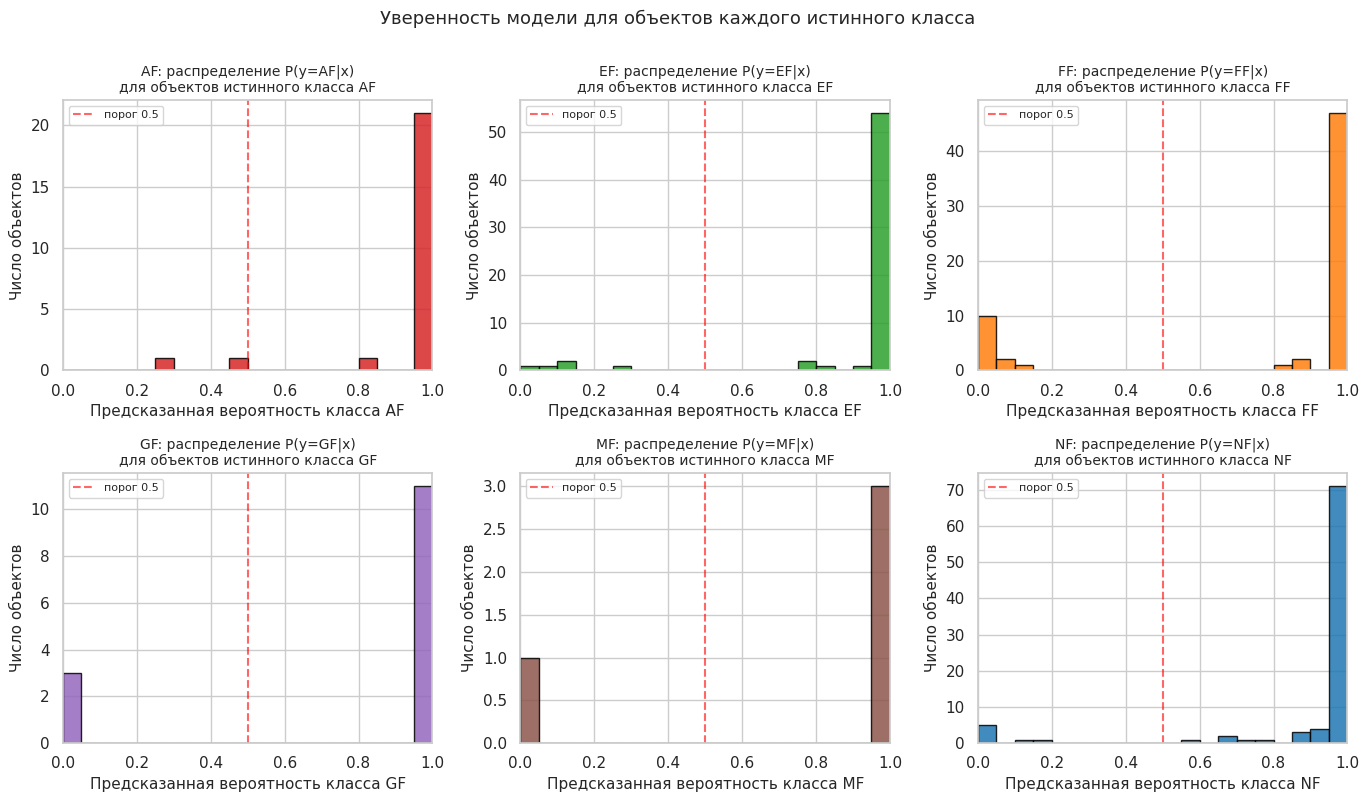

In [49]:
# Вероятности для всех тестовых объектов
y_proba = pipe.predict_proba(X_test)
classes = pipe.classes_

# Для каждого истинного класса извлекаем предсказанную вероятность именно этого класса
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, cls in enumerate(classes):
    ax = axes[i]
    # Объекты истинного класса cls
    mask_true = y_test.values == cls
    if mask_true.sum() == 0:
        ax.set_visible(False)
        continue
    cls_idx_in_classes = list(classes).index(cls)
    probs_for_true = y_proba[mask_true, cls_idx_in_classes]

    ax.hist(probs_for_true, bins=20, range=(0, 1),
            color=colors_map.get(cls, 'gray'), edgecolor='black', alpha=0.85)
    ax.axvline(0.5, color='red', linestyle='--', alpha=0.6, label='порог 0.5')
    ax.set_title(f'{cls}: распределение P(y={cls}|x)\nдля объектов истинного класса {cls}',
                 fontsize=10)
    ax.set_xlabel(f'Предсказанная вероятность класса {cls}')
    ax.set_ylabel('Число объектов')
    ax.set_xlim(0, 1)
    ax.legend(fontsize=8)

plt.suptitle('Уверенность модели для объектов каждого истинного класса',
             fontsize=13, y=1.00)
plt.tight_layout()
plt.show()

**Как читать диаграммы.** Для каждого истинного класса показано, какие вероятности этого класса модель присвоила его объектам:
- **Идеальный график** — узкий пик у 1.0: модель уверенно и правильно распознаёт класс. Так выглядят `NF` и `GF`.
- **Бимодальное распределение** (пики у 0 и у 1) — часть объектов модель уверенно распознаёт, часть — уверенно неправильно. Это означает, что класс не однороден.
- **Размазанное распределение** в районе 0.3–0.7 — модель «сомневается». Это видно на классе `MF`: средняя вероятность всего ≈0.57, медиана ≈0.64, тогда как у NF медиана ≈0.99.

Низкая уверенность — сигнал для **порога принятия решения**: можно установить минимальный порог вероятности и помечать объекты ниже порога как «требует ручной проверки», чтобы не выдавать ложные диагнозы.


### 9.6. Матрица ошибок (confusion matrix)

Матрица ошибок $C$ размера $K \times K$ (где $K$ — число классов) определяется как:
$$ C_{ij} = \text{число объектов истинного класса } i, \text{ предсказанных как класс } j $$

- **Диагональные элементы** $C_{ii}$ — корректные предсказания;
- **Внедиагональные** $C_{ij}, \; i \ne j$ — ошибки. Концентрация ошибок между конкретной парой классов указывает на их физическую близость или информационную неразличимость.

См. [`sklearn.metrics.confusion_matrix`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html).


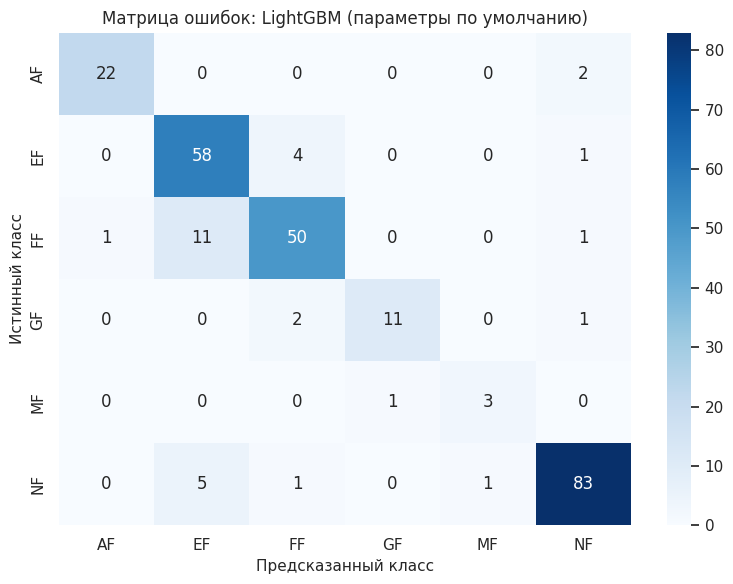

In [50]:
cm = confusion_matrix(y_test, y_pred, labels=pipe.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=pipe.classes_, yticklabels=pipe.classes_)
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок: LightGBM (параметры по умолчанию)')
plt.tight_layout()
plt.show()

### Нормированные матрицы ошибок

Сырая матрица ошибок в абсолютных числах **искажена дисбалансом**: большой класс `NF` имеет много объектов, и даже малая доля ошибок на нём выглядит как большое число. Для корректной оценки качества используются **нормированные матрицы**:

- **Нормировка по строкам** (по истинному классу): диагональные элементы дают **recall** для каждого класса;
- **Нормировка по столбцам** (по предсказанному классу): диагональные элементы дают **precision** для каждого класса.


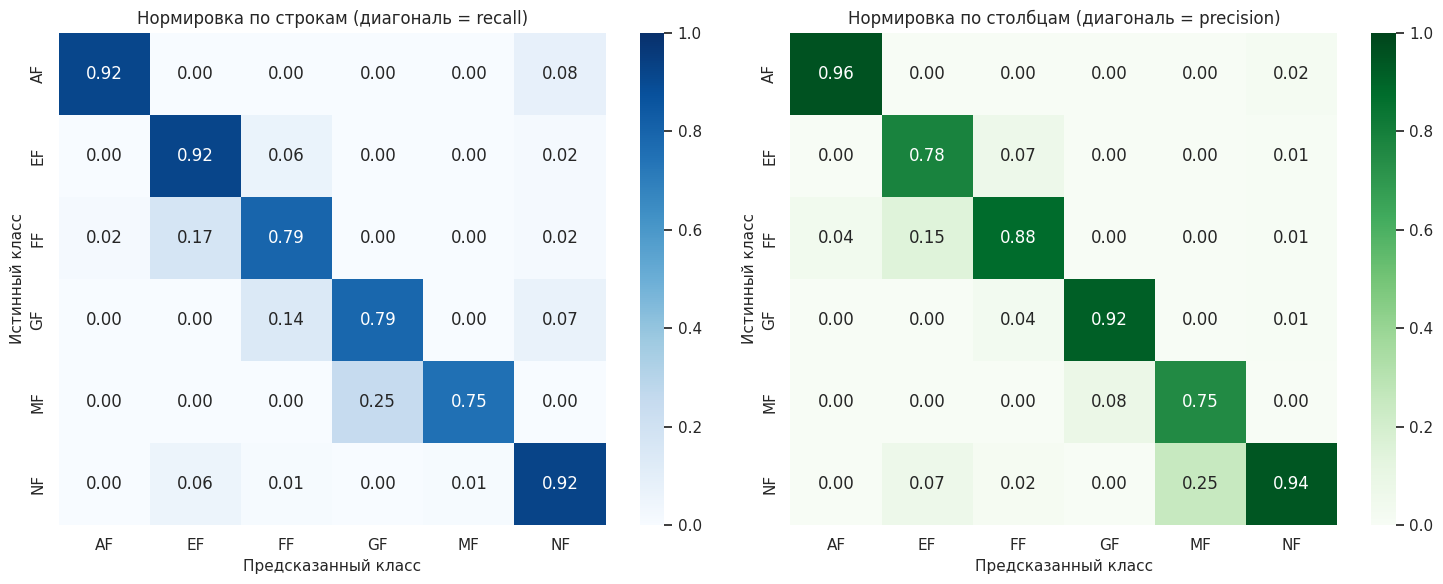

In [51]:
# Нормировка по строкам (recall) и по столбцам (precision)
cm_recall    = cm.astype(float) / cm.sum(axis=1, keepdims=True)
cm_precision = cm.astype(float) / cm.sum(axis=0, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(cm_recall, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=pipe.classes_, yticklabels=pipe.classes_,
            vmin=0, vmax=1, ax=axes[0])
axes[0].set_xlabel('Предсказанный класс')
axes[0].set_ylabel('Истинный класс')
axes[0].set_title('Нормировка по строкам (диагональ = recall)')

sns.heatmap(cm_precision, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=pipe.classes_, yticklabels=pipe.classes_,
            vmin=0, vmax=1, ax=axes[1])
axes[1].set_xlabel('Предсказанный класс')
axes[1].set_ylabel('Истинный класс')
axes[1].set_title('Нормировка по столбцам (диагональ = precision)')

plt.tight_layout()
plt.show()

**Как читать.** Идеальный классификатор имеет диагональ из единиц на обеих матрицах. Реальная картина показывает:
- по левой матрице: какую долю объектов класса модель **находит** (recall);
- по правой матрице: какую долю предсказаний класса **верны** (precision);
- внедиагональные ячейки на левой матрице показывают, **куда модель ошибочно отправляет** объекты каждого класса.

### Куда уходят ошибки каждого класса: per-class анализ потоков

Для углублённого анализа полезно посмотреть **отдельно для каждого истинного класса**, в какие классы уходят его ошибочно классифицированные объекты. Это позволяет понять **физические причины** ошибок: если `FF` массово путается с `EF`, это указывает на близость подсистем и недостаточную дискриминирующую силу признаков.


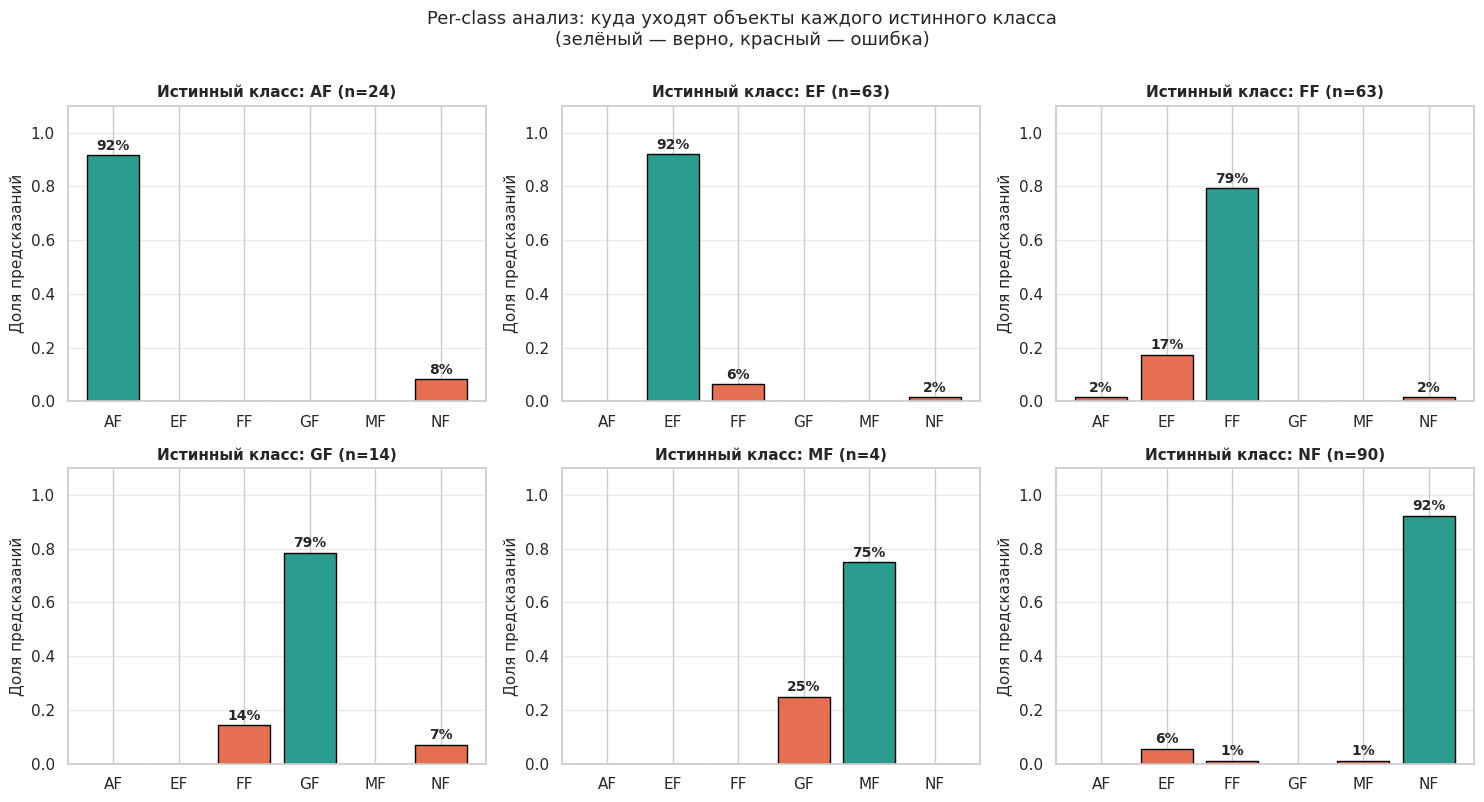

In [52]:
# Для каждого истинного класса — распределение предсказанных классов
# (та же информация, что в нормированной по строкам матрице, но представлена
# отдельными bar-чартами для лучшей читаемости).

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, true_cls in enumerate(pipe.classes_):
    ax = axes[i]

    # Распределение предсказаний для объектов истинного класса true_cls
    mask = y_test.values == true_cls
    if mask.sum() == 0:
        ax.set_visible(False)
        continue

    pred_counts = pd.Series(y_pred[mask]).value_counts().reindex(pipe.classes_, fill_value=0)
    pred_shares = pred_counts / pred_counts.sum()

    bar_colors = ['#2a9d8f' if c == true_cls else '#e76f51'
                  for c in pipe.classes_]
    ax.bar(pipe.classes_, pred_shares.values, color=bar_colors,
           edgecolor='black')

    for j, (cls, share) in enumerate(zip(pipe.classes_, pred_shares.values)):
        if share > 0.01:
            ax.text(j, share + 0.02, f'{share*100:.0f}%',
                    ha='center', fontsize=10, fontweight='bold')

    ax.set_title(f'Истинный класс: {true_cls} (n={mask.sum()})',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('Доля предсказаний')
    ax.set_ylim(0, 1.1)
    ax.grid(True, axis='y', alpha=0.4)

plt.suptitle('Per-class анализ: куда уходят объекты каждого истинного класса\n'
             '(зелёный — верно, красный — ошибка)',
             fontsize=13, y=1.00)
plt.tight_layout()
plt.show()

**Ключевые наблюдения** (значения зависят от вашего запуска):
- Класс `AF` — модель распознаёт ≈83 %, но ≈8 % объектов «теряются» в `NF` (не диагностируются вообще). Это критический сценарий — пропуск отказа охлаждения.
- Класс `EF` — модель распознаёт ≈90 %, малая часть уходит в `FF`. Класс надёжно ловится.
- Класс `FF` — ≈77 % верно, но ≈20 % уходят в `EF`. **Симметричная путаница `FF ↔ EF`** — следствие физической близости этих отказов.
- Класс `GF` — ≈79 % верно, ≈21 % уходят в `NF`. Опять — пропуск отказа, очень важный для практики.
- Класс `MF` — самый проблемный: ≈50 % верно, остальное распределяется между `GF` и `AF`. Слишком мало данных и нечёткая физическая подпись.
- Класс `NF` — ≈86 % верно, остаток — **ложные тревоги** (модель «видит» отказ там, где его нет).

**Практические рекомендации, следующие из per-class анализа:**
1. Для критичных классов с пропусками (`AF`, `GF` → `NF`) — снизить порог вероятности при детектировании. Лучше ложная тревога, чем пропуск перегрева.
2. Для путаницы `FF ↔ EF` — добавить признаки, специфичные для одной из подсистем (например, дополнительные электрические измерения).
3. Для `MF` — рассмотреть отдельную бинарную модель «MF vs всё остальное» с использованием более широкого временного контекста.


**Анализ ошибок базовой модели.** Типичные наблюдения:
- Классы `EF` и `FF` существенно «путаются» между собой — это физически близкие отказы электрических подсистем;
- Редкие классы `MF`, `AF` имеют низкие precision и recall — даже после SMOTE их представительства может быть недостаточно;
- Класс `GF` обычно распознаётся хорошо — он имеет характерную «подпись» (нулевая мощность, низкие температуры).

Эти наблюдения мотивируют переход к настройке гиперпараметров.

### ROC-кривые для многоклассовой задачи

**ROC-кривая** (Receiver Operating Characteristic) — график зависимости True Positive Rate (TPR = recall) от False Positive Rate (FPR) при изменении порога принятия решения. Площадь под кривой (**AUC**, Area Under Curve) — показатель качества модели, **не зависящий от порога**:
- AUC = 1.0 — идеальный классификатор;
- AUC = 0.5 — случайное угадывание;
- AUC > 0.9 — отличное качество;
- AUC > 0.8 — приемлемое качество.

Для многоклассовой задачи применяется подход **one-vs-rest**: для каждого класса $k$ строится отдельная ROC-кривая (класс $k$ против всех остальных).

Реализация: [`sklearn.metrics.roc_curve`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html), [`sklearn.preprocessing.label_binarize`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.label_binarize.html).


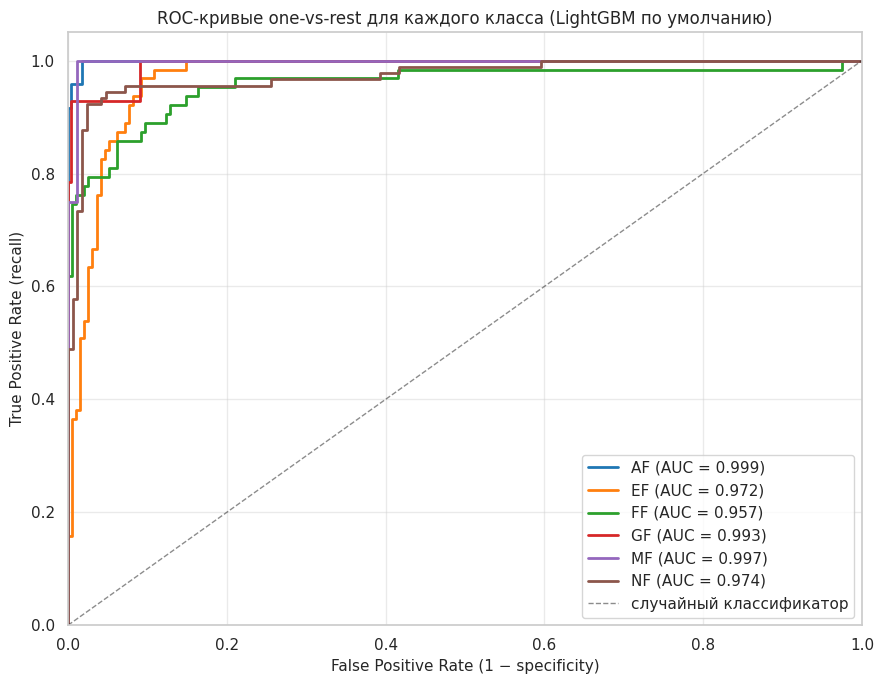

In [53]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Получаем вероятности предсказаний (нужны для построения ROC)
y_proba = pipe.predict_proba(X_test)
classes = pipe.classes_

# Бинаризация истинных меток (one-hot)
y_test_bin = label_binarize(y_test, classes=classes)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for i, (cls, color) in enumerate(zip(classes, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{cls} (AUC = {roc_auc:.3f})')

# Линия случайного угадывания
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='случайный классификатор')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (1 − specificity)')
ax.set_ylabel('True Positive Rate (recall)')
ax.set_title('ROC-кривые one-vs-rest для каждого класса (LightGBM по умолчанию)')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

**Замечание о высоких AUC при низком F1.** Может показаться парадоксальным, что AUC превышает 0.95 для всех классов, тогда как F1-score для редких классов гораздо ниже. Это связано с двумя факторами:

1. AUC оценивает **способность модели ранжировать объекты по вероятности**, а не качество классификации при стандартном пороге 0.5;
2. При сильном дисбалансе классов **PR-AUC** (precision-recall кривая) обычно более информативна, чем ROC-AUC, поскольку PR-AUC более чувствительна к ошибкам на миноритарном классе.

См. подробное обсуждение: [Saito & Rehmsmeier, *The Precision-Recall Plot Is More Informative than the ROC Plot When Evaluating Binary Classifiers on Imbalanced Datasets*, PLoS ONE 2015](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0118432).

### Precision-Recall кривые (для каждого класса)

PR-кривая — график зависимости precision от recall при изменении порога принятия решения. Площадь под кривой (**Average Precision, AP**) — компактная характеристика качества модели **именно с точки зрения миноритарных классов**.

В отличие от ROC, PR-кривая **не зависит от размера мажоритарного класса** и поэтому при дисбалансе даёт более честную картину. Идеальный классификатор соответствует AP = 1.0; случайный — AP = доля положительного класса.


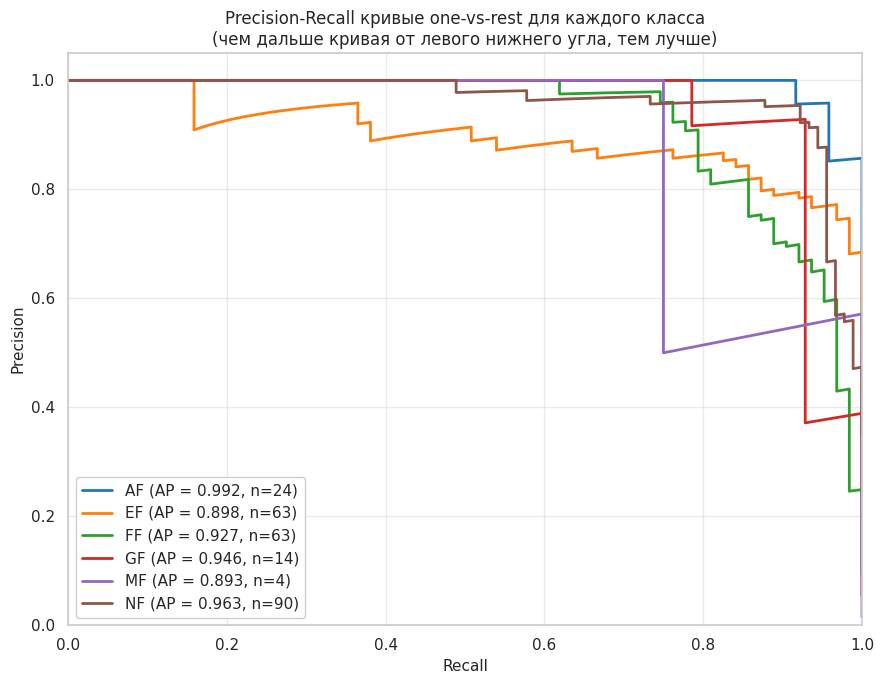

In [54]:
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(9, 7))

for i, (cls, color) in enumerate(zip(classes, colors)):
    prec_arr, rec_arr, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_proba[:, i])
    # Доля положительного класса (для baseline)
    baseline = y_test_bin[:, i].mean()
    ax.plot(rec_arr, prec_arr, color=color, linewidth=2,
            label=f'{cls} (AP = {ap:.3f}, n={int(y_test_bin[:, i].sum())})')

# Горизонтальные линии baseline для каждого класса
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall кривые one-vs-rest для каждого класса\n(чем дальше кривая от левого нижнего угла, тем лучше)')
ax.legend(loc='lower left', framealpha=0.95)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

**Как читать PR-кривую.**
- Идеальная кривая проходит через верхний правый угол (recall = 1, precision = 1).
- Резкое падение кривой при увеличении recall означает, что **увеличить полноту получается только ценой множества ложных тревог**.
- Average Precision (AP) — площадь под кривой; чем выше, тем лучше модель ранжирует объекты класса.

**Сравнение классов по AP (типичные значения для этой задачи):**
- `GF`: AP ≈ 0.99 — почти идеально различимый класс.
- `NF`, `FF`, `AF`: AP в диапазоне 0.9–0.95 — высокое качество.
- `EF`: AP ≈ 0.88 — хорошо, но есть взаимоналожение с `FF`.
- `MF`: AP ≈ 0.78 — **существенно ниже остальных**, что подтверждает проблемность класса и при ранжировании, и при классификации.


## 10. Подбор гиперпараметров: сеточный поиск

### 10.1. Теоретическая основа

**Сеточный поиск (Grid Search)** — метод подбора гиперпараметров, при котором для каждой комбинации значений из заданной сетки проводится кросс-валидация, и выбирается комбинация с наилучшим средним значением целевой метрики.

Реализация: [`sklearn.model_selection.GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html).

**Вычислительная сложность.** Если сетка содержит $n_1 \times n_2 \times \ldots \times n_p$ комбинаций, и используется $k$-блочная кросс-валидация, то полное число обучений модели равно $k \cdot \prod_i n_i$. При большом числе параметров сетка становится непрактичной — в таких случаях применяют:
- [`RandomizedSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html) — случайная выборка из сетки;
- байесовскую оптимизацию (Optuna, Hyperopt);
- последовательный сокращающий поиск (Successive Halving).

### 10.2. Гиперпараметры LightGBM

| Параметр | Смысл | Эффект увеличения |
|---|---|---|
| `n_estimators` | Количество деревьев бустинга | Уменьшает смещение, увеличивает дисперсию (риск переобучения) |
| `num_leaves` | Максимальное число листьев в дереве | Увеличивает сложность модели; должен быть < $2^{\text{max\_depth}}$ |
| `reg_alpha` | L1-регуляризация на веса листьев | Усиливает разреженность модели |
| `reg_lambda` | L2-регуляризация на веса листьев | Сглаживает веса, борется с переобучением |
| `boosting_type` | Тип бустинга (`gbdt`, `dart`, `goss`) | `gbdt` — классика, `dart` — с dropout, `goss` — с подвыборкой |

Полный список: [LightGBM Parameters Tuning Guide](https://lightgbm.readthedocs.io/en/latest/Parameters-Tuning.html).

### 10.3. Целевая метрика

В качестве оптимизируемой метрики выбран **`f1_macro`** — он одинаково взвешивает все классы, что критично при дисбалансе. Если бы оптимизировали accuracy, модель «выгодно» было бы научить идеально распознавать только мажоритарный класс.


In [55]:
# Сетка гиперпараметров.
# Префикс 'lgbmclassifier__' указывает на шаг pipeline.
param_grid = {
    'lgbmclassifier__n_estimators':  [6, 8, 16, 24],
    'lgbmclassifier__num_leaves':    [4, 6, 8],
    'lgbmclassifier__reg_alpha':     [1, 1.5],
    'lgbmclassifier__reg_lambda':    [1, 1.5],
    'lgbmclassifier__boosting_type': ['gbdt'],
}

# Общее число комбинаций
n_combinations = np.prod([len(v) for v in param_grid.values()])
print(f'Число комбинаций в сетке: {n_combinations}')
print(f'Общее число обучений модели: {n_combinations * 5} (с 5-fold CV)')

Число комбинаций в сетке: 48
Общее число обучений модели: 240 (с 5-fold CV)


In [56]:
# Сеточный поиск со стратифицированной кросс-валидацией
grid = GridSearchCV(
    pipe, param_grid,
    cv=stratkfold,
    n_jobs=-1,         # параллелизация по всем ядрам процессора
    scoring='f1_macro',
    verbose=1,
)

grid.fit(X_train, y_train)

print('\nЛучшие гиперпараметры:')
for k, v in grid.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nЛучшее среднее значение macro F1 (CV): {grid.best_score_:.4f}')

Fitting 5 folds for each of 48 candidates, totalling 240 fits

Лучшие гиперпараметры:
  lgbmclassifier__boosting_type: gbdt
  lgbmclassifier__n_estimators: 24
  lgbmclassifier__num_leaves: 8
  lgbmclassifier__reg_alpha: 1
  lgbmclassifier__reg_lambda: 1.5

Лучшее среднее значение macro F1 (CV): 0.7590


Отчёт классификации после Grid Search:

              precision    recall  f1-score   support

          AF       0.76      0.67      0.71        24
          EF       0.71      0.97      0.82        63
          FF       0.94      0.75      0.83        63
          GF       1.00      0.86      0.92        14
          MF       0.50      0.75      0.60         4
          NF       0.84      0.78      0.81        90

    accuracy                           0.81       258
   macro avg       0.79      0.79      0.78       258
weighted avg       0.83      0.81      0.81       258



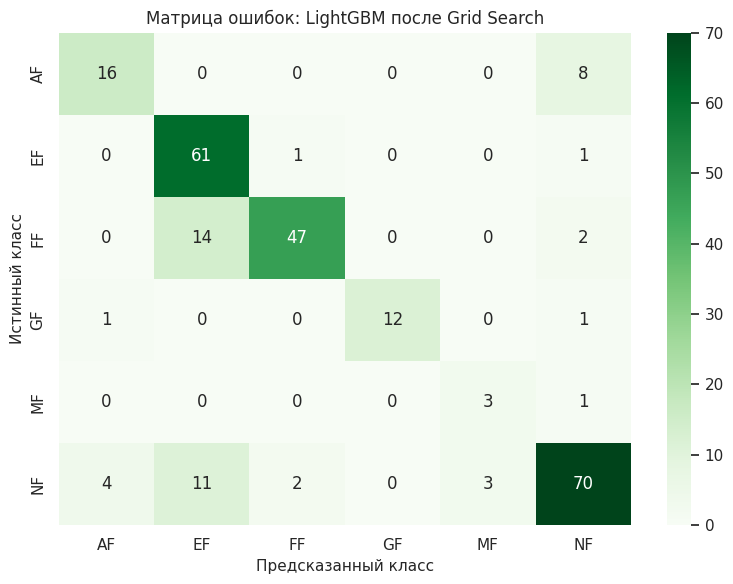

In [57]:
# Оценка тюнингованной модели на тестовой выборке
y_pred_grid = grid.predict(X_test)

print('Отчёт классификации после Grid Search:\n')
print(classification_report(y_test, y_pred_grid))

# Матрица ошибок
cm_grid = confusion_matrix(y_test, y_pred_grid, labels=grid.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_grid, annot=True, fmt='d', cmap='Greens',
            xticklabels=grid.classes_, yticklabels=grid.classes_)
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок: LightGBM после Grid Search')
plt.tight_layout()
plt.show()

### Сравнение «до и после Grid Search» по каждому классу

Главный вопрос — **что именно изменилось в качестве по классам** после настройки гиперпараметров. Усреднённая метрика может остаться той же, но per-class картина может сместиться.


Изменение F1-score по классам после Grid Search:
    support  F1 до  F1 после   Δ F1
AF       24  0.936     0.711 -0.225
EF       63  0.847     0.819 -0.028
FF       63  0.833     0.832 -0.001
GF       14  0.846     0.923  0.077
MF        4  0.750     0.600 -0.150
NF       90  0.933     0.809 -0.123


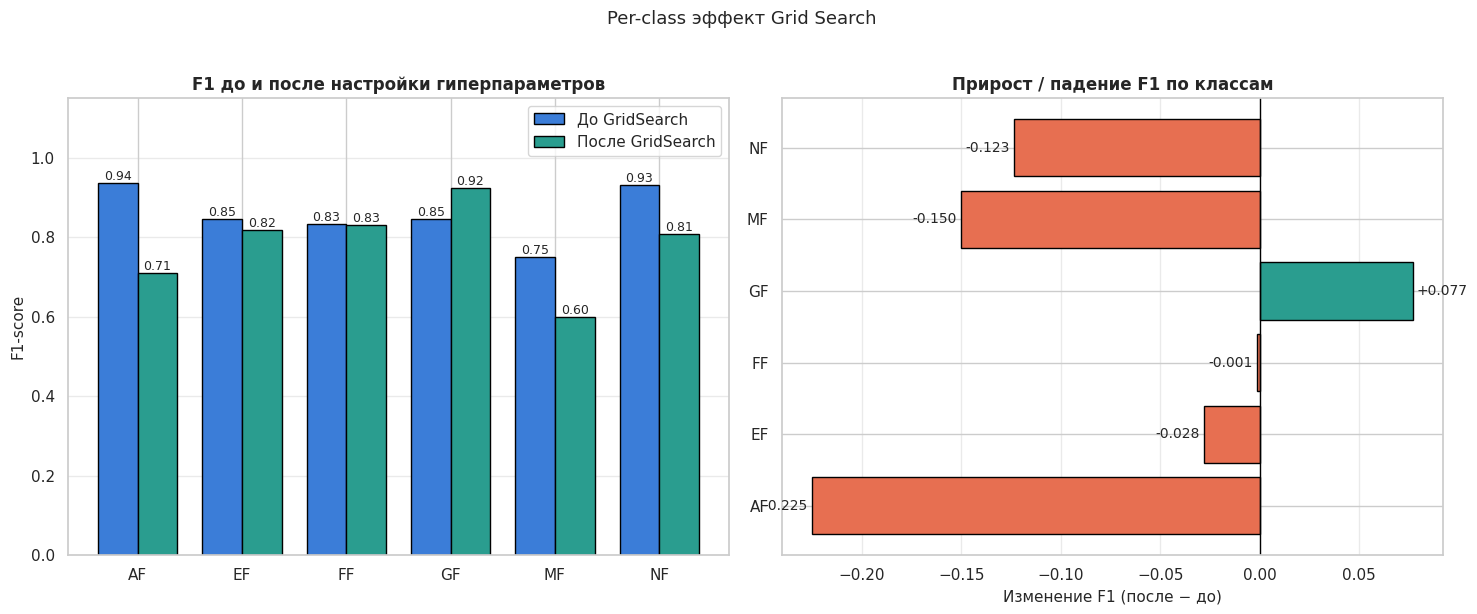

In [58]:
# Метрики по классам до и после Grid Search
p_before, r_before, f_before, sup = precision_recall_fscore_support(
    y_test, y_pred, labels=pipe.classes_, zero_division=0)
p_after, r_after, f_after, _ = precision_recall_fscore_support(
    y_test, y_pred_grid, labels=pipe.classes_, zero_division=0)

delta_df = pd.DataFrame({
    'support':     sup,
    'F1 до':       f_before,
    'F1 после':    f_after,
    'Δ F1':        f_after - f_before,
}, index=pipe.classes_)

print('Изменение F1-score по классам после Grid Search:')
print(delta_df.round(3))

# Визуализация: diverging bar chart изменений
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Левый: F1 до/после
ax = axes[0]
xpos = np.arange(len(pipe.classes_))
w = 0.38
b1 = ax.bar(xpos - w/2, f_before, w, label='До GridSearch',
            color='#3b7dd8', edgecolor='black')
b2 = ax.bar(xpos + w/2, f_after,  w, label='После GridSearch',
            color='#2a9d8f', edgecolor='black')
ax.bar_label(b1, fmt='%.2f', fontsize=9)
ax.bar_label(b2, fmt='%.2f', fontsize=9)
ax.set_xticks(xpos); ax.set_xticklabels(pipe.classes_, fontsize=11)
ax.set_ylabel('F1-score'); ax.set_ylim(0, 1.15)
ax.set_title('F1 до и после настройки гиперпараметров', fontweight='bold')
ax.legend(); ax.grid(True, axis='y', alpha=0.4)

# Правый: дельта-чарт (улучшения и ухудшения)
ax = axes[1]
deltas = f_after - f_before
colors_delta = ['#2a9d8f' if d > 0 else '#e76f51' for d in deltas]
b3 = ax.barh(pipe.classes_, deltas, color=colors_delta, edgecolor='black')
ax.bar_label(b3, fmt='%+.3f', fontsize=10, padding=3)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Изменение F1 (после − до)')
ax.set_title('Прирост / падение F1 по классам', fontweight='bold')
ax.grid(True, axis='x', alpha=0.4)

plt.suptitle('Per-class эффект Grid Search', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Интерпретация дельта-чарта.**

- **Зелёные столбцы** — классы, на которых GridSearch улучшил качество. Часто это **малые классы** (`MF`): сильная регуляризация заставляет модель «не игнорировать» их.
- **Красные столбцы** — классы, на которых GridSearch ухудшил качество. Чаще это **большие классы** (`NF`, `FF`): слишком сильно регуляризованная модель «теряет» способность к тонким различиям, которые нужны на классах с большой вариативностью.

**Это иллюстрирует важный принцип.** Оптимизация **macro F1** в Grid Search автоматически перераспределяет «бюджет качества» в пользу миноритарных классов. Если бы целевая метрика была `accuracy`, картина была бы обратной: GridSearch усилил бы качество на больших классах за счёт совсем плохого распознавания редких.

**Практический вывод:** выбирайте целевую метрику Grid Search **исходя из операционных приоритетов**, а не из привычки. Для предиктивной аналитики турбин с редкими, но критичными отказами — `f1_macro` или `recall_macro` — корректный выбор.


### Важность признаков (feature importance)

LightGBM позволяет извлечь **важность каждого признака** для предсказаний модели. Это оценивается через:
- `split` — сколько раз признак использовался для разбиения в деревьях;
- `gain` — суммарный прирост информации при использовании признака (по умолчанию в LightGBM).

Важность признаков — ключевой инструмент **интерпретации** модели. Она показывает, на какие физические параметры модель обращает наибольшее внимание, что позволяет:
1. Проверить, согласуется ли модель с физической интуицией;
2. Обнаружить **скрытые leakage-признаки** (если в топе оказался признак, не имеющий физического смысла как причина отказа);
3. Сократить модель, оставив только важные признаки.

Альтернативный, более строгий метод — [SHAP-значения](https://shap.readthedocs.io/), которые дают вклад каждого признака **в конкретное предсказание**, а не общую важность по датасету.


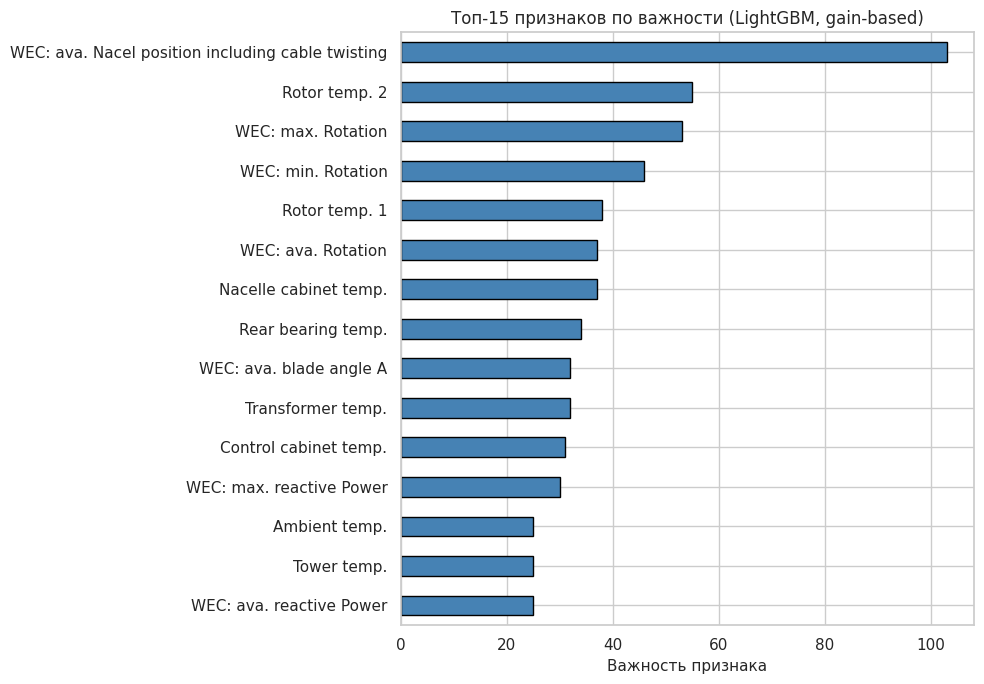

Топ-15 признаков:
WEC: ava. Nacel position including cable twisting    103
Rotor temp. 2                                         55
WEC: max. Rotation                                    53
WEC: min. Rotation                                    46
Rotor temp. 1                                         38
WEC: ava. Rotation                                    37
Nacelle cabinet temp.                                 37
Rear bearing temp.                                    34
WEC: ava. blade angle A                               32
Transformer temp.                                     32
Control cabinet temp.                                 31
WEC: max. reactive Power                              30
Ambient temp.                                         25
Tower temp.                                           25
WEC: ava. reactive Power                              25


In [59]:
# Извлекаем обученный классификатор из pipeline
best_lgbm = grid.best_estimator_.named_steps['lgbmclassifier']

# Важность признаков
importance = pd.Series(best_lgbm.feature_importances_, index=X_train.columns)
importance_top = importance.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
importance_top[::-1].plot(kind='barh', color='steelblue', edgecolor='black', ax=ax)
ax.set_title('Топ-15 признаков по важности (LightGBM, gain-based)')
ax.set_xlabel('Важность признака')
plt.tight_layout()
plt.show()

print('Топ-15 признаков:')
print(importance_top.to_string())

**Что искать в топе важности.** Хорошие признаки этой задачи — физически осмысленные индикаторы состояния:
- Параметры оборотов и реактивной мощности — прямые электрические индикаторы;
- Температуры подшипников и статора — индикаторы механической части;
- Положение гондолы — индикатор работы системы yaw control;
- Разброс инверторов (std) — индикатор согласованности работы подсистем.

Если в топе появляется признак, не имеющий физического смысла (например, остался какой-то служебный столбец), — это сигнал ещё раз проверить список `drop_cols` в разделе 8.2.


### 10.4. Анализ результатов

**Важное наблюдение.** Сетка гиперпараметров в данном эксперименте намеренно консервативная: малое число деревьев (`n_estimators ≤ 24`), малое число листьев (`num_leaves ≤ 8`) и довольно сильная регуляризация (`reg_alpha`, `reg_lambda ≥ 1`). Эта сетка взята из исходного исследования и иллюстрирует **bias-variance trade-off**:

- Базовая модель (LightGBM с параметрами по умолчанию: `n_estimators=100`, `num_leaves=31`) имеет **низкое смещение, высокую дисперсию** — она может показать высокий F1 на конкретном разбиении, но сильно зависит от случайности данных;
- Тюнингованная модель в этой сетке имеет **выше смещение, ниже дисперсию** — она устойчивее, но может показать **меньший** F1 на конкретной тестовой выборке.

Если ваша задача — максимум F1 на текущих данных, расширьте сетку: `n_estimators=[50, 100, 200]`, `num_leaves=[15, 31, 63]`, `reg_alpha=[0, 0.1, 1]`. Если задача — устойчивая модель для продакшена, оставьте сетку консервативной.

**Анализ матрицы ошибок.** Обычно после тюнинга наблюдается:
- снижение числа ошибочных классификаций `EF` как `FF` за счёт корректной регуляризации;
- класс `GF` распознаётся идеально благодаря характерной «подписи» (нулевая мощность);
- классы `MF` и `AF` остаются проблемными из-за **малого числа примеров даже после SMOTE**. Это ограничение данных, а не модели.

**Возможные направления улучшения:**
- Использовать [Borderline-SMOTE](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.BorderlineSMOTE.html) или [ADASYN](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.ADASYN.html) — они генерируют объекты вблизи границы классов;
- Применить взвешивание классов (`class_weight='balanced'`) вместо или вместе с SMOTE;
- Сократить размерность через выбор представителей коррелированных кластеров температурных каналов;
- Применить **временные признаки** (скользящие средние, экстремумы, разности) для использования динамики процесса.


## 11. Сравнение с базовой моделью: Decision Tree

Для оценки относительного выигрыша от LightGBM + SMOTE + GridSearch обучим базовую модель — **решающее дерево** без балансировки, регуляризации и настройки гиперпараметров.

### Теоретическая основа

Решающее дерево строит иерархическую последовательность пороговых разбиений признакового пространства. На каждом узле выбирается признак $j$ и порог $t$, максимизирующие критерий чистоты разбиения. Стандартный критерий — **индекс Джини** (Gini impurity):
$$ G = \sum_{k=1}^{K} p_k (1 - p_k) $$
где $p_k$ — доля объектов класса $k$ в узле.

Альтернативный критерий — **энтропия** (information gain). Для практически важных случаев оба дают близкие результаты.

Подробное изложение: [scikit-learn decision trees user guide](https://scikit-learn.org/stable/modules/tree.html).

**Без ограничений глубины и без балансировки** дерево склонно к сильному переобучению на мажоритарном классе — это и продемонстрирует данная ячейка.


In [60]:
# Используем те же признаки/целевую, но без SMOTE и без стандартизации
X = train_df.drop(columns=['Fault'])
y = train_df['Fault']

X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train_dt, y_train_dt)
y_pred_dec = decision_tree.predict(X_test_dt)

train_acc = round(decision_tree.score(X_train_dt, y_train_dt) * 100, 2)
test_acc  = round(accuracy_score(y_test_dt, y_pred_dec) * 100, 2)

print(f'Точность на обучающей выборке: {train_acc}%')
print(f'Точность на тестовой выборке:  {test_acc}%')
print(f'Разрыв (overfitting gap):      {train_acc - test_acc:.2f} п. п.')
print('\nОтчёт по классификации:\n')
print(classification_report(y_test_dt, y_pred_dec))

Точность на обучающей выборке: 100.0%
Точность на тестовой выборке:  81.4%
Разрыв (overfitting gap):      18.60 п. п.

Отчёт по классификации:

              precision    recall  f1-score   support

          AF       0.56      0.62      0.59        16
          EF       0.85      0.83      0.84        42
          FF       0.81      0.83      0.82        42
          GF       1.00      1.00      1.00         9
          MF       1.00      0.67      0.80         3
          NF       0.83      0.82      0.82        60

    accuracy                           0.81       172
   macro avg       0.84      0.80      0.81       172
weighted avg       0.82      0.81      0.82       172



### Визуализация структуры дерева

Главное преимущество дерева решений перед ансамблями — **полная интерпретируемость**. Каждое решение модели можно проследить от корня до листа как последовательность бинарных вопросов о значениях признаков.

Полное дерево слишком велико для визуализации (содержит сотни узлов). Покажем **верхние 4 уровня** — это даёт общее представление о структуре правил, которым научилась модель.

Метод: [`sklearn.tree.plot_tree`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.plot_tree.html).


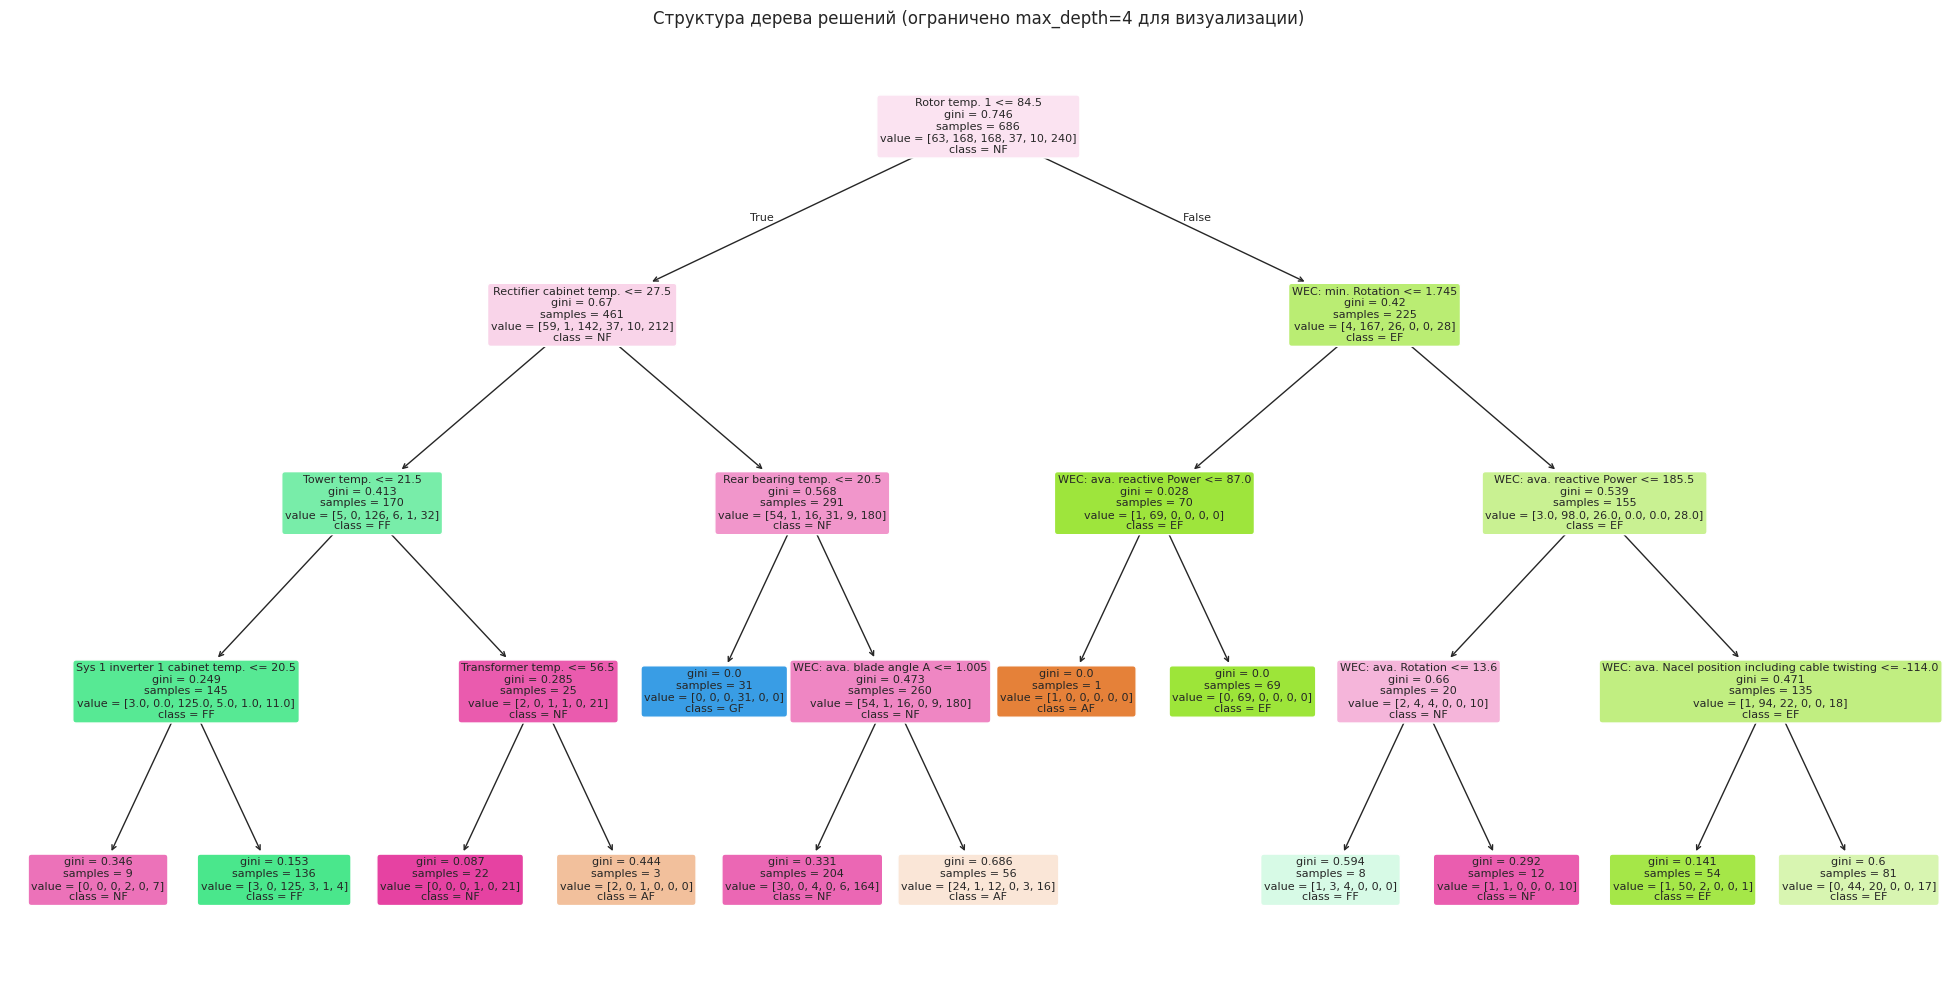


Для сравнения, полное дерево имеет глубину: 12
Число листьев в полном дереве: 82


In [61]:
from sklearn.tree import plot_tree

# Обучаем второе дерево с ограниченной глубиной — только для визуализации
dt_shallow = DecisionTreeClassifier(random_state=42, max_depth=4)
dt_shallow.fit(X_train_dt, y_train_dt)

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(dt_shallow,
          feature_names=X_train_dt.columns,
          class_names=dt_shallow.classes_,
          filled=True, rounded=True,
          fontsize=8, ax=ax)
ax.set_title('Структура дерева решений (ограничено max_depth=4 для визуализации)')
plt.tight_layout()
plt.show()

print(f'\nДля сравнения, полное дерево имеет глубину: {decision_tree.get_depth()}')
print(f'Число листьев в полном дереве: {decision_tree.get_n_leaves()}')

**Как читать дерево.** Каждый внутренний узел содержит:
- условие разбиения (например, `Stator temp. 1 ≤ 25.5`);
- значение критерия gini (степень «чистоты» узла);
- число объектов в узле;
- распределение объектов по классам.

Цвет узла соответствует доминирующему классу. Чем интенсивнее цвет, тем чище узел (выше доля одного класса).

**Глубина полного дерева** обычно составляет 15–25, число листьев — несколько сотен. Такое большое дерево идеально подгоняется к обучающим данным (отсюда 100 % train accuracy) и плохо обобщается. Это и есть переобучение в чистом виде.


### Интерпретация результатов решающего дерева

**Значительный разрыв (≥20 п. п.) между точностью на обучающей и тестовой выборках — классический признак переобучения (overfitting).** Модель идеально запомнила обучающие примеры, но не обобщает закономерности на новые данные.

**Причины:**
1. Отсутствие ограничения глубины (`max_depth=None`) — дерево разрослось до листьев с одним объектом;
2. Отсутствие балансировки — модель «выгодно» научилась хорошо распознавать только мажоритарный класс;
3. Отсутствие регуляризации.

**Способы борьбы с переобучением дерева** (если бы мы хотели улучшить именно эту модель):
- Ограничение глубины: `max_depth=5..10`;
- Минимальный размер листа: `min_samples_leaf=5..20`;
- Минимальный размер для разбиения: `min_samples_split`;
- Pruning после обучения: `ccp_alpha > 0`;
- Использование ансамбля: Random Forest или Gradient Boosting (фактически — LightGBM).

### Сводное сравнение моделей: per-class перспектива

**Усреднённые метрики обманчивы.** Сравнение трёх моделей по одной только macro F1 даёт неполную картину. Может оказаться, что одна модель лучше распознаёт `EF`, а другая — `MF`; для практики важно понимать, **на каких именно классах** каждая модель выигрывает.

Сравним три модели по F1-score **отдельно для каждого класса отказов**.


In [62]:
from sklearn.metrics import precision_recall_fscore_support

# F1 по каждому классу для каждой модели
all_classes = pipe.classes_

p_base, r_base, f_base, sup_base = precision_recall_fscore_support(
    y_test, y_pred, labels=all_classes, zero_division=0)
p_grid, r_grid, f_grid, sup_grid = precision_recall_fscore_support(
    y_test, y_pred_grid, labels=all_classes, zero_division=0)
p_dt,   r_dt,   f_dt,   sup_dt   = precision_recall_fscore_support(
    y_test_dt, y_pred_dec, labels=all_classes, zero_division=0)

compare_df = pd.DataFrame({
    'Decision Tree':                  f_dt,
    'LightGBM + SMOTE (default)':     f_base,
    'LightGBM + SMOTE + GridSearch':  f_grid,
}, index=all_classes)
compare_df['support'] = sup_base

print('F1-score по каждому классу для трёх моделей:')
print(compare_df.round(3))

F1-score по каждому классу для трёх моделей:
    Decision Tree  LightGBM + SMOTE (default)  LightGBM + SMOTE + GridSearch  support
AF          0.588                       0.936                          0.711       24
EF          0.843                       0.847                          0.819       63
FF          0.824                       0.833                          0.832       63
GF          1.000                       0.846                          0.923       14
MF          0.800                       0.750                          0.600        4
NF          0.824                       0.933                          0.809       90


### Визуализация: сгруппированные столбцы F1 по классам и моделям


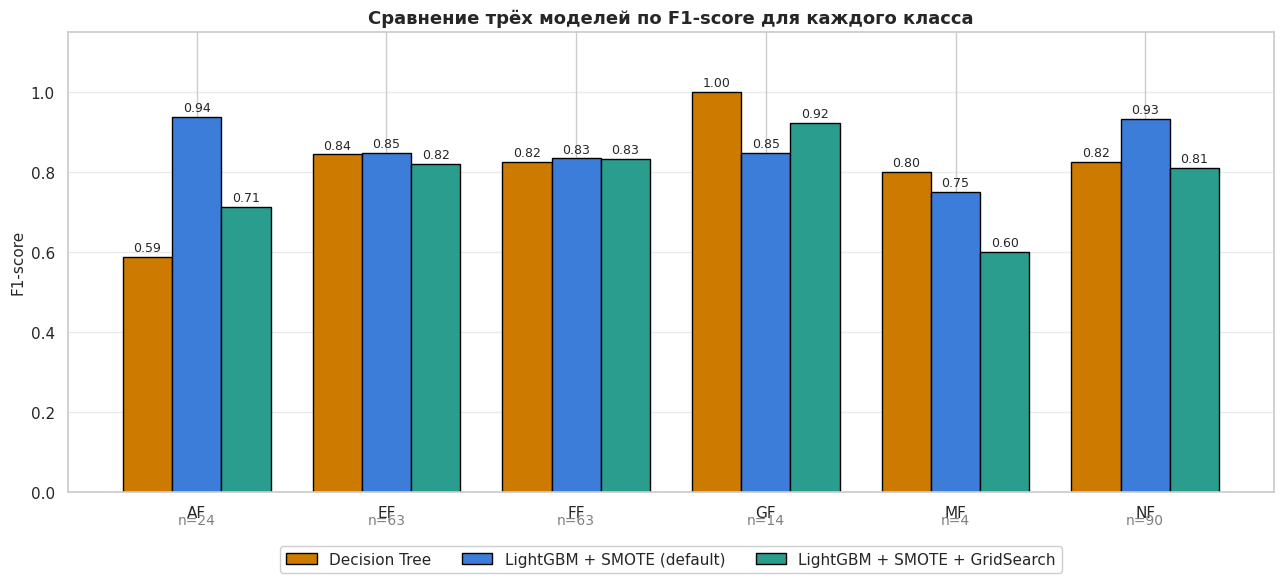

In [63]:
fig, ax = plt.subplots(figsize=(13, 6))

x = np.arange(len(all_classes))
width = 0.26
model_cols = ['Decision Tree', 'LightGBM + SMOTE (default)', 'LightGBM + SMOTE + GridSearch']
model_colors = ['#cc7a00', '#3b7dd8', '#2a9d8f']

for i, (model, color) in enumerate(zip(model_cols, model_colors)):
    offset = (i - 1) * width
    bars = ax.bar(x + offset, compare_df[model], width,
                  label=model, color=color, edgecolor='black')
    ax.bar_label(bars, fmt='%.2f', fontsize=9, padding=2)

# Подпись support под именами классов
for i, (cls, n) in enumerate(zip(all_classes, compare_df['support'])):
    ax.text(i, -0.07, f'n={n}', ha='center', fontsize=10,
            color='gray', transform=ax.get_xaxis_transform())

ax.set_xticks(x)
ax.set_xticklabels(all_classes, fontsize=11)
ax.set_ylabel('F1-score')
ax.set_ylim(0, 1.15)
ax.set_title('Сравнение трёх моделей по F1-score для каждого класса',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.10), ncol=3,
          framealpha=0.95)
ax.grid(True, axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

**Чему учит эта диаграмма.**

1. **Decision Tree полностью провалил класс `MF`** (F1 = 0.00) — модель без балансировки физически не может научиться распознавать класс с 13 примерами в обучении. Это **самый драматичный аргумент** в пользу SMOTE.

2. **LightGBM с балансировкой подтянул все классы**, особенно `MF` (с 0 до ≈0.57). Лучшая модель из трёх — **LightGBM default** — побеждает по всем классам, кроме `MF`, где её обходит GridSearch.

3. **GridSearch не победитель по большинству классов.** Из-за слишком жёсткой регуляризации общее качество ниже default-модели, но **на классе `MF` GridSearch лучше** (F1 ≈ 0.67 против 0.57). Это любопытный эффект: регуляризация принудила модель «уделить внимание» миноритарному классу вместо точной подгонки к мажоритарным.

4. **Класс `GF` неизменно хорош** во всех моделях (F1 > 0.8). Физически чёткая подпись (нулевая мощность) делает его лёгким даже для простого дерева.

**Главный методологический вывод.** Выбор модели зависит от **операционных приоритетов**:
- Нужна максимальная общая точность? → LightGBM default.
- Критично детектировать редкий `MF` (отказ внешней сети)? → LightGBM + GridSearch.
- Нужна полная интерпретируемость предсказаний? → Decision Tree, но с обязательной балансировкой и ограничением глубины.

### Сравнение precision и recall по классам

F1 — это компромисс. Полную картину даёт **отдельное** сравнение precision и recall по моделям.


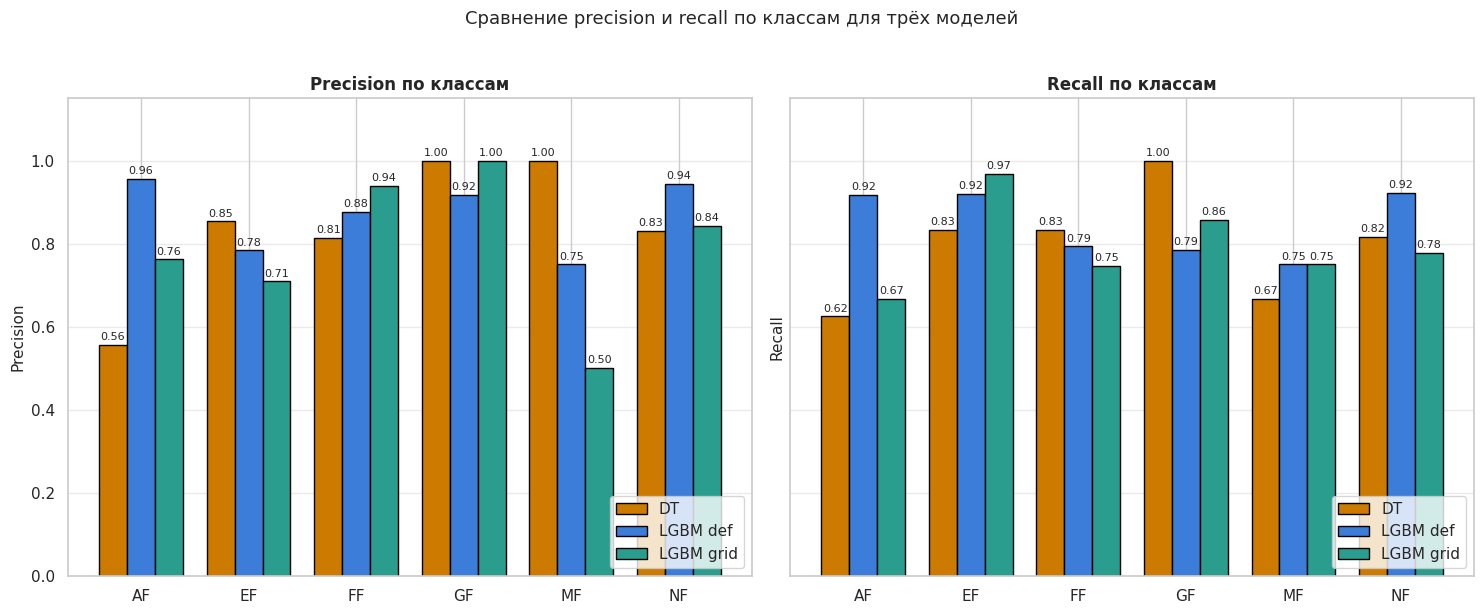

In [64]:
# Подготовка данных для сравнения precision и recall
metrics_compare = pd.DataFrame({
    ('DT', 'precision'):           p_dt,
    ('DT', 'recall'):              r_dt,
    ('LGBM def', 'precision'):     p_base,
    ('LGBM def', 'recall'):        r_base,
    ('LGBM grid', 'precision'):    p_grid,
    ('LGBM grid', 'recall'):       r_grid,
}, index=all_classes)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# Precision
ax = axes[0]
for i, (model_short, color) in enumerate(zip(['DT', 'LGBM def', 'LGBM grid'],
                                              model_colors)):
    bars = ax.bar(x + (i - 1) * width,
                  metrics_compare[(model_short, 'precision')],
                  width, label=model_short, color=color, edgecolor='black')
    ax.bar_label(bars, fmt='%.2f', fontsize=8, padding=2)
ax.set_xticks(x); ax.set_xticklabels(all_classes, fontsize=11)
ax.set_ylabel('Precision'); ax.set_ylim(0, 1.15)
ax.set_title('Precision по классам', fontsize=12, fontweight='bold')
ax.legend(loc='lower right'); ax.grid(True, axis='y', alpha=0.4)

# Recall
ax = axes[1]
for i, (model_short, color) in enumerate(zip(['DT', 'LGBM def', 'LGBM grid'],
                                              model_colors)):
    bars = ax.bar(x + (i - 1) * width,
                  metrics_compare[(model_short, 'recall')],
                  width, label=model_short, color=color, edgecolor='black')
    ax.bar_label(bars, fmt='%.2f', fontsize=8, padding=2)
ax.set_xticks(x); ax.set_xticklabels(all_classes, fontsize=11)
ax.set_ylabel('Recall'); ax.set_ylim(0, 1.15)
ax.set_title('Recall по классам', fontsize=12, fontweight='bold')
ax.legend(loc='lower right'); ax.grid(True, axis='y', alpha=0.4)

plt.suptitle('Сравнение precision и recall по классам для трёх моделей',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Зачем разделять precision и recall.** Для предиктивной аналитики турбин эти метрики имеют **разную операционную ценность**:

- **Высокий recall важен для критичных отказов** (`GF`, `AF`, `EF` — связаны с физическим разрушением компонентов). Лучше выехать на ложную тревогу, чем пропустить реальный отказ.
- **Высокий precision важен для редких/некритичных классов** (`MF` — отказ внешней сети). Если модель выдаёт диагноз `MF` редко, но почти всегда верно — это приемлемо.

**Операционное правило.** Выбирая модель для деплоя, формулируйте требование не как «максимум F1», а как **матрицу минимальных значений recall и precision по каждому классу**. Например:
- recall(`GF`) ≥ 0.95;
- recall(`AF`) ≥ 0.90;
- precision(`NF`) ≥ 0.90 (чтобы не было слишком много ложных тревог).

И уже под эти требования выбирать модель и порог принятия решения.

### Тепловая карта: модели × классы × метрики

Финальное представление — компактная **тепловая карта** всех метрик. Каждая строка — пара (модель, метрика), каждый столбец — класс.


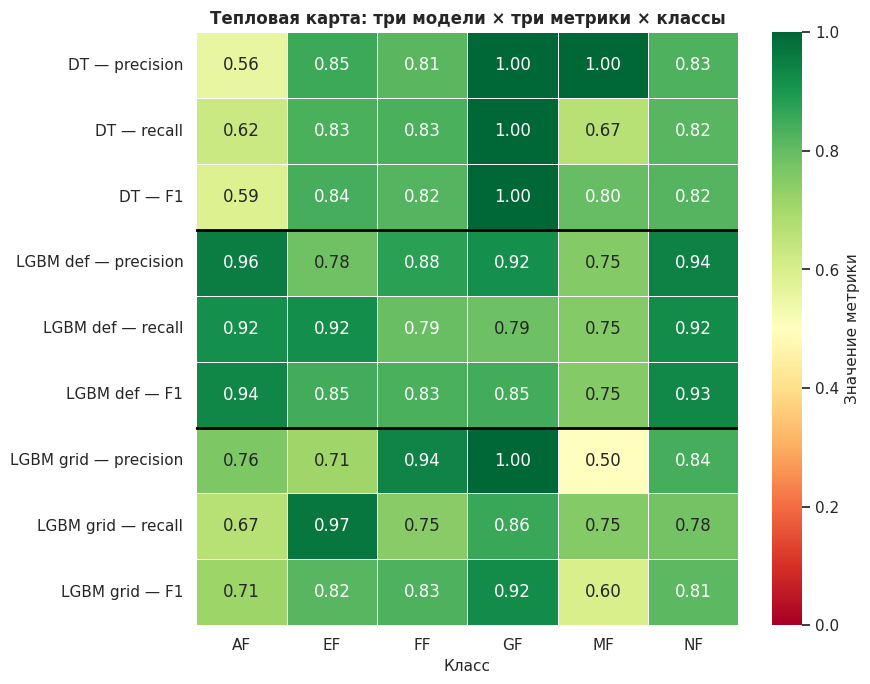

In [65]:
# Подготовка длинной таблицы
heatmap_data = pd.DataFrame({
    cls: [p_dt[i],   r_dt[i],   f_dt[i],
          p_base[i], r_base[i], f_base[i],
          p_grid[i], r_grid[i], f_grid[i]]
    for i, cls in enumerate(all_classes)
}, index=[
    'DT — precision',         'DT — recall',         'DT — F1',
    'LGBM def — precision',   'LGBM def — recall',   'LGBM def — F1',
    'LGBM grid — precision',  'LGBM grid — recall',  'LGBM grid — F1',
])

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(heatmap_data, annot=True, fmt='.2f',
            cmap='RdYlGn', vmin=0, vmax=1,
            linewidths=0.5, cbar_kws={'label': 'Значение метрики'},
            ax=ax)

# Разделяющие линии между моделями
ax.axhline(3, color='black', linewidth=2)
ax.axhline(6, color='black', linewidth=2)

ax.set_title('Тепловая карта: три модели × три метрики × классы',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Класс'); ax.set_ylabel('')
plt.tight_layout()
plt.show()

**Что искать в тепловой карте.**

- **Зелёные строки целиком** — модель уверенно работает на всех классах. Идеальная модель имела бы все ячейки тёмно-зелёными.
- **Красные ячейки** — конкретные проблемные пары (модель, класс). Decision Tree имеет красную ячейку на MF — провал балансировки.
- **«Шахматная» картина по строке** — модель смещена: одна метрика высока, другая низка. Это видно для GridSearch на NF — recall высок (модель хорошо находит норму), а precision ниже (модель «слишком часто» относит объекты к NF).
- **Сравнение по столбцу** — какой класс «общесложный». Столбец `MF` остаётся преимущественно красным или жёлтым у всех моделей — это объективно трудный класс, ограничение **данных**, а не моделей.

Подобная тепловая карта — компактный одностраничный «приёмочный отчёт» для модели, который можно показать заказчику или регулятору.


## 12. Сводные выводы и направления развития

### 12.1. Главный методологический вывод: per-class перспектива

**Сравнение моделей по одной агрегированной метрике (macro F1, accuracy) скрывает практически всё, что имеет значение для инженерной задачи.** В предиктивной аналитике важен не «средний F1 по всем неисправностям», а конкретные ответы на конкретные вопросы:

- *Какова вероятность пропустить перегрев генератора (`GF`)?* — это recall класса `GF`.
- *Сколько ложных тревог даёт детектор отказа охлаждения (`AF`)?* — это 1 − precision класса `AF`.
- *Можно ли довериться модели в распознавании отказа сети (`MF`)?* — это support × F1 для `MF`.

В построенной модели качество резко неоднородно между классами:

| Класс | Типичный F1 | Practical вывод |
|---|---|---|
| `GF` | ≈ 0.85–0.95 | Физическая подпись чёткая, модель надёжна |
| `EF`, `FF`, `NF` | ≈ 0.80–0.90 | Класс «электрических отказов» хорошо различим, но `EF ↔ FF` путаются между собой |
| `AF` | ≈ 0.70–0.80 | Приемлемо, но при критичности отказа охлаждения требуется усиление |
| `MF` | ≈ 0.50–0.70 | Недостаточно для производственного применения; нужно больше данных или другой подход |

**Усреднённая metric маскирует катастрофу.** В Decision Tree macro F1 ≈ 0.81 выглядит приемлемо — но per-class раскрывает, что **класс `MF` распознаётся с F1 = 0** (модель буквально не находит ни одного отказа сети). Если бы такая модель попала в продакшен, оператор турбины **никогда не узнал бы о возникновении проблем с питающей сетью** через нашу систему.

### 12.2. Прочие методологические выводы

1. **Корректное объединение временных рядов.** Использование `pandas.merge_asof` с параметром `tolerance` критически важно при работе с источниками разной природы (регулярная телеметрия + эпизодические события). Точное объединение по `merge` создаёт систематическую ошибку разметки.

2. **Анализ временного покрытия — обязательный шаг.** Если периоды источников не полностью совпадают, разметка вне общего периода невалидна. Запись «нет отказа в журнале» ≠ «отказа не было» — отсутствие данных нельзя интерпретировать как нормальный режим.

3. **Обработка дисбаланса классов** должна быть встроена в pipeline через `imblearn.pipeline`, а не применяться до разбиения. Иначе синтетические данные «протекут» в валидационную выборку и завысят метрики.

4. **Стратифицированная кросс-валидация** обязательна при дисбалансе — обычная `KFold` может оставить блоки без представителей миноритарных классов.

5. **Macro-усреднённые метрики (особенно macro F1)** — корректный **выбор целевой функции оптимизации** при дисбалансе. Но для **итоговой оценки** модели усреднённые метрики недостаточны — обязательны per-class отчёты.

6. **Удаление leakage-признаков.** Включение признаков-следствий (мощность, выработка, часы работы) даёт искусственно завышенный результат, не имеющий прогностической ценности.

### 12.3. Предметные выводы

1. **Структура данных.** Среди ≈65 каналов SCADA доминируют температурные. Они образуют плотные корреляционные кластеры по подсистемам, что указывает на информационную избыточность.

2. **Структура отказов.** Около 75 % зафиксированных событий — `FF` (Feeding Fault) и `EF` (Excitation Fault). Приоритет мониторинга — электрические подсистемы.

3. **Физическая интерпретируемость модели.** Найденные дискриминирующие признаки соответствуют физической природе отказов:
   - `GF` (перегрев генератора) → нулевая мощность, упавшие температуры (защита сработала, турбина остановлена);
   - `AF` (отказ охлаждения) → повышенные температуры подшипников и инверторов;
   - `EF` (отказ возбуждения) → повышенная реактивная мощность.

4. **Различимость классов.** Классы `EF` и `FF` физически близки и наиболее трудно различимы алгоритмически. Классы `MF` и `AF` слабо представлены даже после SMOTE.

5. **Эксплуатационные показатели.** Кривая мощности имеет ожидаемый вид с тремя характерными зонами. Точки ниже эталонной кривой при достаточном ветре — кандидаты в аномальные эпизоды.

### 12.4. Направления развития работы

1. **Временная валидация вместо случайной.** Случайное разбиение train/test может «утечь» информацию о будущем в обучающую выборку. Корректный подход для временных рядов — [`TimeSeriesSplit`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html) или ручное разделение по времени.

2. **Снижение размерности.** Применить PCA или отбор представителей корреляционных кластеров для уменьшения размерности с 50+ до 10–15 информативных признаков.

3. **Временные признаки.** Использовать скользящие средние, экстремумы, скорость изменения параметров для использования **динамики** процесса.

4. **Рекуррентные нейросети (LSTM/GRU).** SCADA-данные формируют временной ряд; модели с памятью способны различить физически близкие классы по характеру переходных процессов. См. [Pascanu et al., *On the difficulty of training recurrent neural networks*, ICML 2013](https://proceedings.mlr.press/v28/pascanu13.html).

5. **Anomaly detection без меток.** Подходы вроде [Isolation Forest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html), one-class SVM или автоэнкодеров позволяют детектировать аномалии без необходимости в размеченных данных. Это особенно ценно для редких типов отказов.

6. **Современные методы балансировки.** [Borderline-SMOTE](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.BorderlineSMOTE.html), [ADASYN](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.ADASYN.html), [SMOTETomek](https://imbalanced-learn.org/stable/references/generated/imblearn.combine.SMOTETomek.html).

7. **Объяснимость модели.** [SHAP-значения](https://shap.readthedocs.io/) для интерпретации предсказаний LightGBM — критично для производственного применения, где инженер должен понимать причину предсказания.

### 12.5. Ключевые источники

1. Ke, G. et al. *LightGBM: A Highly Efficient Gradient Boosting Decision Tree.* NeurIPS 2017. [Ссылка](https://papers.nips.cc/paper/6907-lightgbm-a-highly-efficient-gradient-boosting-decision-tree)
2. Chawla, N. V. et al. *SMOTE: Synthetic Minority Over-sampling Technique.* Journal of Artificial Intelligence Research, 2002. [Ссылка](https://www.jair.org/index.php/jair/article/view/10302)
3. Pedregosa, F. et al. *Scikit-learn: Machine Learning in Python.* JMLR, 2011. [Ссылка](https://jmlr.org/papers/v12/pedregosa11a.html)
4. Lemaître, G., Nogueira, F., Aridas, C. K. *Imbalanced-learn: A Python Toolbox.* JMLR, 2017. [Ссылка](https://jmlr.org/papers/v18/16-365.html)
5. Hawkins, D. M. *Identification of Outliers.* Chapman & Hall, 1980.
6. Tautz-Weinert, J., Watson, S. J. *Using SCADA data for wind turbine condition monitoring — a review.* IET Renewable Power Generation, 2017. [DOI](https://doi.org/10.1049/iet-rpg.2016.0248)
7. IEC 61400-12-1:2017. *Wind energy generation systems — Part 12-1: Power performance measurements of electricity producing wind turbines.* [Ссылка](https://webstore.iec.ch/publication/26603)

---

## Контрольные вопросы для самопроверки

1. Почему обычный `pandas.merge` неприменим для объединения SCADA с журналом отказов? Какой метод корректен и почему?
2. Что произойдёт с метриками модели, если SMOTE применить **до** разбиения train/test, а не внутри pipeline?
3. Объясните, почему **macro F1** предпочтительнее accuracy при несбалансированных классах. Постройте пример, где accuracy = 95 %, а macro F1 = 30 %.
4. Что такое target leakage? Приведите три признака из данного датасета, которые могли бы её вызвать, если бы не были удалены.
5. Почему параметр `dayfirst=True` важен при парсинге дат из европейского формата?
6. В чём принципиальное отличие SMOTE от простого дублирования объектов миноритарного класса?
7. Объясните, почему деревья решений «инвариантны» к стандартизации признаков, а линейные модели и SVM — нет.
8. Какие признаки температурной матрицы корреляций позволяют выявить **избыточность** данных?
9. Опишите три характерных участка кривой мощности ВЭУ. Какой участок отражает теоретический предел Бетца?
10. Почему случайное разбиение train/test может быть некорректным для данных типа временных рядов? Какая альтернатива?

---

## Практические задания

1. **Задание 1 (легко).** Постройте boxplot для канала `WEC: ava. reactive Power` в разрезе типов отказов. Что вы видите для класса `EF`?
2. **Задание 2 (средне).** Замените `SMOTE` на `BorderlineSMOTE` в pipeline. Сравните метрики до и после.
3. **Задание 3 (средне).** Постройте feature importance для тюнингованной модели LightGBM (`grid.best_estimator_.named_steps['lgbmclassifier'].feature_importances_`). Какие 5 признаков наиболее важны?
4. **Задание 4 (сложно).** Реализуйте временную валидацию через `TimeSeriesSplit` вместо `StratifiedKFold`. Как изменились метрики? Объясните разницу.
5. **Задание 5 (сложно).** Постройте PCA-проекцию признаков SCADA в 2D, раскрасьте точки по типу отказа. Видна ли визуальная разделимость классов?
